# Notebook 06: **generación de texto, generación con LLM y minería de texto**

**Curso:** Procesamiento de Lenguaje Natural — Especialización en Inteligencia Artificial, Universidad de Cundinamarca
**Docente:** Paul Alexander Díaz Montaña
**Autor:** Yohan Nicolás Gómez Castañeda
**Base:** laboratorio de clase *Course 3 – Week 4* (Moroney, `dlaicourse`): predicción de la siguiente palabra con `Tokenizer`, relleno de secuencias y `Embedding` + `Bidirectional(LSTM)`.

---

## Objetivo

Cerrar el laboratorio con los tres temas que van del texto generado al texto analizado en masa. Los dos
primeros comparten la tarea —producir lenguaje— pero no el método: en la sección 2 los modelos **se entrenan
desde cero** sobre el corpus EFE y solo saben lo que ese corpus contiene; en la sección 3 el texto lo produce un
**modelo grande preentrenado al que se le da una instrucción**, sin ajustar un solo parámetro. La sección 4 invierte
la dirección: en lugar de generar texto, extrae de las 998 noticias los patrones, las colocaciones y los temas que
un lector humano no podría contar a mano.

| Sección | Tema | Pregunta que responde |
|---|---|---|
| 1 | Corpus de generación | ¿Qué subconjunto del corpus EFE alimenta a los generadores y cuánto vocabulario cubre? |
| 2 | **Text generation** | ¿Cuánto mejora una red recurrente frente a una línea base de n-gramas? ¿Qué hacen la temperatura, el top-k y la búsqueda voraz? |
| 3 | **Generación de texto usando LLM** | ¿En qué se diferencia instruir un modelo preentrenado de entrenar uno propio, y qué se gana y se arriesga? |
| 4 | **Text mining** | ¿Qué patrones, colocaciones y temas emergen de las 998 noticias sin supervisión? |
| 5 | Hallazgos | — |

El corpus y las decisiones de preprocesamiento son las del notebook 01: noticias de la agencia EFE
(CoNLL-2002, mayo de 2000), tildes conservadas, cabecera de agencia eliminada, *stopwords* de NLTK sin
negaciones y lematización de spaCy para las representaciones.

## 0. Configuración del entorno

In [1]:
# Funciona igual en Google Colab y en local. En Colab clona el repositorio para disponer del paquete `pln_lab`
# y descarga el modelo de spaCy si hace falta.
import importlib.util, os, subprocess, sys
from pathlib import Path

# NLTK debe autorizarse antes de cualquier descarga cuando la salida pasa por un proxy; en Colab es inocuo.
os.environ.setdefault("NLTK_ALLOW_PROXIED_URLOPEN", "1")
# Silencia los avisos de compilación de TensorFlow (no afectan al resultado, solo ensucian la salida).
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

REPO = "https://github.com/Nicolas2322/lab-procesamiento-texto.git"
EN_COLAB = "google.colab" in sys.modules

def raiz_del_repositorio() -> Path:
    for candidata in [Path.cwd(), *Path.cwd().parents]:
        if (candidata / "src" / "pln_lab").exists():
            return candidata
    if EN_COLAB:
        destino = Path("/content/lab-procesamiento-texto")
        if not destino.exists():
            subprocess.run(["git", "clone", "-q", REPO, str(destino)], check=True)
        return destino
    raise FileNotFoundError("Ejecute el notebook desde la carpeta del repositorio.")

RAIZ = raiz_del_repositorio()
sys.path.insert(0, str(RAIZ / "src"))

if importlib.util.find_spec("es_core_news_md") is None:
    subprocess.run([sys.executable, "-m", "spacy", "download", "es_core_news_md", "-q"], check=True)
for paquete, modulo in [("tensorflow-cpu", "tensorflow"), ("wordcloud", "wordcloud"), ("gensim", "gensim")]:
    if importlib.util.find_spec(modulo) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", paquete], check=True)

print("Raíz del repositorio:", RAIZ, "| Colab:", EN_COLAB)

Raíz del repositorio: /home/claude/lab-procesamiento-texto | Colab: False


In [2]:
import json, random, re, time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk, spacy

from pln_lab.corpus import cargar_documentos_efe, documentos_a_dataframe, destokenizar
from pln_lab.preprocesamiento import (
    NEGACIONES, cargar_spacy, es_palabra, quitar_cabecera_agencia, stopwords_nltk, tokenizar,
)
from pln_lab.generacion import (
    ModeloNGramas, TokenizadorPalabras, distinct_n, elegir, generar_con_red, longitud_media,
    tasa_repeticion,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DIR_FIG = RAIZ / "notebooks" / "figuras"; DIR_RES = RAIZ / "notebooks" / "resultados"
for d in (DIR_FIG, DIR_RES):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
AZUL, ROJO, VERDE, GRIS, NARANJA, MORADO = "#2563eb", "#dc2626", "#16a34a", "#6b7280", "#d97706", "#7c3aed"
pd.set_option("display.max_colwidth", 90)

METRICAS = {}

def guardar_figura(nombre):
    plt.savefig(DIR_FIG / f"{nombre}.png"); plt.show()

def pct(x, d=1):
    return f"{100 * x:.{d}f} %"

print("spaCy", spacy.__version__, "| NLTK", nltk.__version__, "| pandas", pd.__version__)

spaCy 3.8.16 | NLTK 3.10.3 | pandas 3.0.2


## 1. Corpus de trabajo para la generación

Entrenar un modelo de lenguaje desde cero con 2 CPUs impone un límite duro: el corpus completo (369.171 tokens)
produciría cientos de miles de ejemplos de entrenamiento y un vocabulario de más de 40.000 tipos, es decir, una
capa de salida enorme para un presupuesto de minutos. El laboratorio de clase resuelve un problema equivalente
recortando el material (usa un puñado de canciones o sonetos), y aquí se hace lo mismo de forma explícita:

- se toman las **dos primeras oraciones con contenido** de cada noticia (las primeras oraciones de una nota de
  agencia condensan el hecho noticioso: es el material más informativo por token);
- se elimina la **cabecera de agencia** (*«Madrid, 25 may (EFE). -»*) y las líneas de agenda con separadores
  `=====`, que son ruido de formato;
- cada línea se **recorta a 30 palabras**, para que las secuencias de entrada tengan una longitud comparable;
- el vocabulario se limita a las **5.000 palabras más frecuentes** y el resto se sustituye por el token `<oov>`.

El mismo material y el mismo vocabulario alimentan al modelo de n-gramas y a la red recurrente, de modo que la
comparación de perplejidades sea justa.

In [3]:
documentos = cargar_documentos_efe()
corpus = documentos_a_dataframe(documentos)

MAX_PALABRAS, N_ORACIONES, VOCAB_MAX = 30, 2, 5000

lineas = []
for doc in documentos:
    tomadas = 0
    for oracion in doc.oraciones:
        texto = quitar_cabecera_agencia(destokenizar([w for w, _, _ in oracion]))
        palabras = texto.split()
        # Se descartan fragmentos demasiado cortos (cabeceras, guiones) y las líneas de agenda.
        if len(palabras) < 8 or "=====" in texto:
            continue
        lineas.append(" ".join(palabras[:MAX_PALABRAS]))
        tomadas += 1
        if tomadas == N_ORACIONES:
            break

tokenizador = TokenizadorPalabras(num_words=VOCAB_MAX).fit_on_textos(lineas)
vocab_recortado = {p for p, i in tokenizador.word_index.items() if i <= VOCAB_MAX}
cobertura = sum(c for p, c in tokenizador.conteos.items() if p in vocab_recortado) / sum(tokenizador.conteos.values())

METRICAS["corpus_generacion"] = {
    "lineas": len(lineas),
    "palabras": int(sum(len(l.split()) for l in lineas)),
    "tokens_tokenizador": int(sum(tokenizador.conteos.values())),
    "vocabulario_completo": len(tokenizador.word_index),
    "vocabulario_usado": VOCAB_MAX,
    "cobertura_tokens": round(float(cobertura), 4),
}
display(pd.Series(METRICAS["corpus_generacion"], name="valor").to_frame())
for l in lineas[:3]:
    print("•", l)

,valor
lineas,1978.0000
palabras,57172.0000
tokens_tokenizador,55872.0000
vocabulario_completo,9142.0000
vocabulario_usado,5000.0000
cobertura_tokens,0.9259


• El Abogado General del Estado, Daryl Williams, subrayó hoy la necesidad de tomar medidas para proteger al sistema judicial australiano frente a una página de internet que imposibilita el cumplimiento
• La petición del Abogado General tiene lugar después de que un juez del Tribunal Supremo del estado de Victoria (Australia) se viera forzado a disolver un jurado popular y suspender
• Izquierda Unida de Santander presentó hoy su nuevo boletín trimestral "Ciudad", una publicación de la que se distribuirán 10.000 ejemplares preferentemente en los barrios del municipio donde la colación cuenta


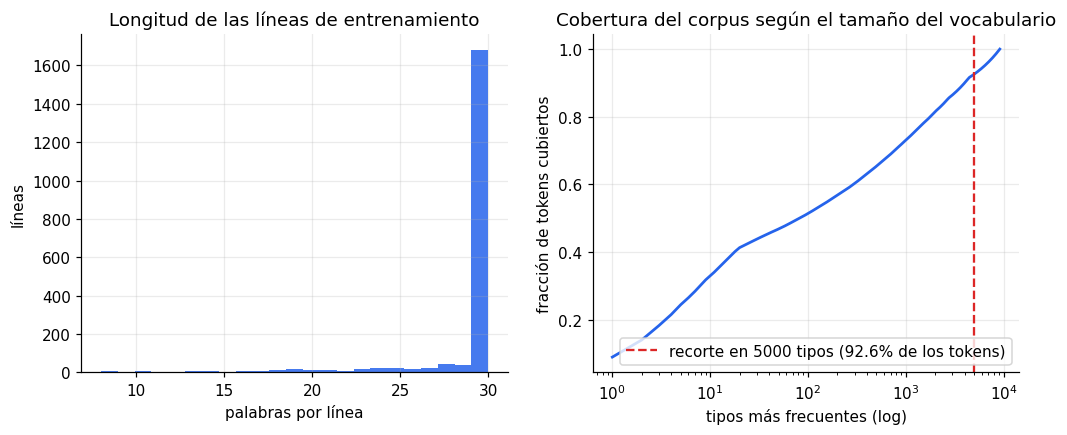

Líneas: 1978 | tipos: 9142 | cobertura con 5000: 92.59%


In [4]:
# ¿Cuánto del corpus cubre cada tamaño de vocabulario? La curva justifica el recorte en 5.000.
frecuencias = np.array([c for _, c in tokenizador.conteos.most_common()])
acumulada = np.cumsum(frecuencias) / frecuencias.sum()
tamanos = np.arange(1, len(frecuencias) + 1)

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
ejes[0].hist([len(l.split()) for l in lineas], bins=23, color=AZUL, alpha=0.85)
ejes[0].set(title="Longitud de las líneas de entrenamiento", xlabel="palabras por línea", ylabel="líneas")
ejes[1].plot(tamanos, acumulada, color=AZUL, lw=1.8)
ejes[1].axvline(VOCAB_MAX, color=ROJO, ls="--", label=f"recorte en {VOCAB_MAX} tipos ({cobertura:.1%} de los tokens)")
ejes[1].set(title="Cobertura del corpus según el tamaño del vocabulario", xlabel="tipos más frecuentes (log)",
            ylabel="fracción de tokens cubiertos", xscale="log")
ejes[1].legend(loc="lower right")
guardar_figura("fig06_01_corpus_generacion")
print(f"Líneas: {len(lineas)} | tipos: {len(tokenizador.word_index)} | cobertura con {VOCAB_MAX}: {cobertura:.2%}")

**Análisis.** El recorte deja 1.978 líneas y 57.172 palabras, alrededor del 15 % del corpus
completo: suficiente para que la red vea patrones sintácticos del español periodístico y poco suficiente para que
entrene en minutos. La curva de cobertura muestra por qué el límite de 5.000 palabras no es arbitrario: con ese
vocabulario se cubre el 92,6 % de los tokens, aunque el vocabulario real del subconjunto sea de
9.142 tipos. Es la consecuencia directa de la ley de Zipf medida en el notebook 01 —las palabras
frecuentes concentran las ocurrencias—, y el precio es que uno de cada 13 tokens se convierte en
`<oov>`: casi todos son nombres propios y cifras, exactamente la información que un modelo entrenado con tan poco
texto no podría aprender de todas formas.

## 2. Text generation: modelos entrenados desde cero

Generar texto es, en los dos modelos de esta sección, la misma operación repetida: estimar
$P(w_t \mid w_{1..t-1})$ y muestrear de esa distribución. Lo que cambia es cómo se representa el contexto.

- El **modelo de n-gramas** supone que solo importan las $n-1$ palabras anteriores y estima la probabilidad
  contando: $P(w_t \mid w_{t-n+1..t-1}) = C(\text{contexto}, w_t) / C(\text{contexto})$. Es transparente y se
  entrena en milisegundos, pero cualquier contexto no visto tiene probabilidad cero, de ahí el **suavizado**.
- La **red recurrente** del laboratorio de clase aprende una representación densa de las palabras
  (`Embedding`) y un estado que resume el contexto (`Bidirectional(LSTM)`), de modo que contextos parecidos pero
  no idénticos comparten información.

### 2.1 Línea base: n-gramas con suavizado add-k

Se implementa a mano en `pln_lab.generacion.ModeloNGramas`. El suavizado es **add-k (Lidstone)**: se suma una
constante $k$ a cada conteo antes de normalizar, de forma que ningún n-grama tenga probabilidad cero y la
perplejidad sea finita. Se evalúa con una partición de validación del 10 % de las líneas, la misma que usará la red.

In [5]:
# Se sustituyen las palabras fuera del vocabulario por <oov> para que el modelo de n-gramas y la red
# compartan exactamente el mismo espacio de salida.
tokenizadas = [[p if p in vocab_recortado else "<oov>" for p in tokenizador.tokenizar(l)] for l in lineas]

indices = np.arange(len(tokenizadas))
np.random.default_rng(SEED).shuffle(indices)
corte = int(0.9 * len(indices))
idx_entrena, idx_valida = indices[:corte], indices[corte:]
entrena = [tokenizadas[i] for i in idx_entrena]
valida = [tokenizadas[i] for i in idx_valida]
print(f"Líneas de entrenamiento: {len(entrena)} | de validación: {len(valida)}")

filas = []
for n in (2, 3):
    for k in (0.01, 0.1, 1.0):
        modelo_n = ModeloNGramas(n=n, k=k).entrenar(entrena)
        filas.append({
            "n": n, "k": k,
            "contextos": len(modelo_n.conteos),
            "perplejidad (entrenamiento)": modelo_n.perplejidad(entrena),
            "perplejidad (validación)": modelo_n.perplejidad(valida),
        })
tabla_ngramas = pd.DataFrame(filas)
METRICAS["ngramas"] = {"tabla": tabla_ngramas.round(2).to_dict("records")}
display(tabla_ngramas.style.format({"perplejidad (entrenamiento)": "{:.1f}", "perplejidad (validación)": "{:.1f}"}))

Líneas de entrenamiento: 1780 | de validación: 198


,n,k,contextos,perplejidad (entrenamiento),perplejidad (validación)
0,2,0.010000,4937,58.0,253.7
1,2,0.100000,4937,175.3,407.2
2,2,1.000000,4937,707.1,963.5
3,3,0.010000,22033,40.1,631.5
4,3,0.100000,22033,266.0,1199.9
5,3,1.000000,22033,1535.8,2513.9


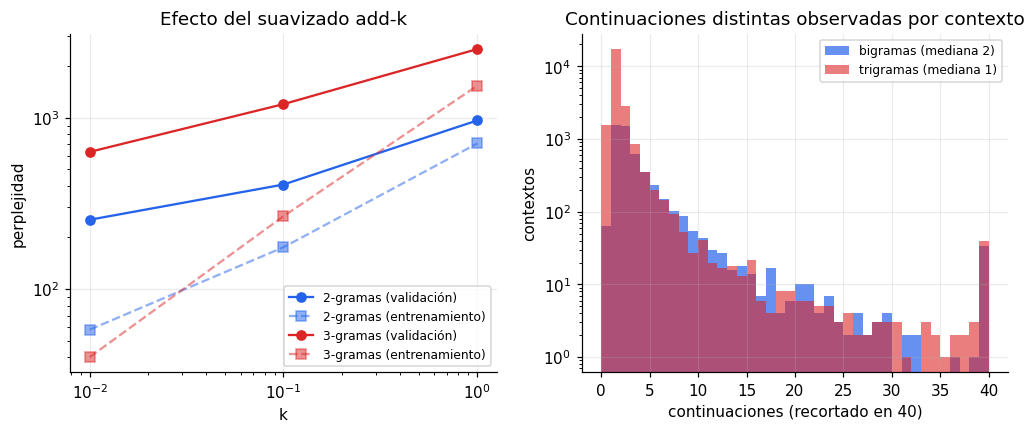

Perplejidad en validación — bigramas: 407.2 | trigramas: 1199.9
Contextos con una única continuación — bigramas: 30.8% | trigramas: 73.2%


In [6]:
bigramas = ModeloNGramas(n=2, k=0.1).entrenar(entrena)
trigramas = ModeloNGramas(n=3, k=0.1).entrenar(entrena)
ppl_bi = bigramas.perplejidad(valida)
ppl_tri = trigramas.perplejidad(valida)
METRICAS["ngramas"].update({
    "vocabulario": bigramas.tamano_vocabulario,
    "contextos_bigramas": len(bigramas.conteos),
    "contextos_trigramas": len(trigramas.conteos),
    "ppl_validacion_bigramas": round(float(ppl_bi), 2),
    "ppl_validacion_trigramas": round(float(ppl_tri), 2),
    "ppl_entrenamiento_bigramas": round(float(bigramas.perplejidad(entrena)), 2),
    "ppl_entrenamiento_trigramas": round(float(trigramas.perplejidad(entrena)), 2),
})

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
for n, color in ((2, AZUL), (3, ROJO)):
    sub = tabla_ngramas[tabla_ngramas.n == n]
    ejes[0].plot(sub.k, sub["perplejidad (validación)"], "o-", color=color, label=f"{n}-gramas (validación)")
    ejes[0].plot(sub.k, sub["perplejidad (entrenamiento)"], "s--", color=color, alpha=0.5,
                 label=f"{n}-gramas (entrenamiento)")
ejes[0].set(title="Efecto del suavizado add-k", xlabel="k", ylabel="perplejidad", xscale="log", yscale="log")
ejes[0].legend(fontsize=8)

# Cuántas continuaciones distintas admite cada contexto: mide la dispersión que obliga a suavizar.
cont_bi = np.array([len(c) for c in bigramas.conteos.values()])
cont_tri = np.array([len(c) for c in trigramas.conteos.values()])
ejes[1].hist(np.clip(cont_bi, 0, 40), bins=40, color=AZUL, alpha=0.7, label=f"bigramas (mediana {np.median(cont_bi):.0f})")
ejes[1].hist(np.clip(cont_tri, 0, 40), bins=40, color=ROJO, alpha=0.6, label=f"trigramas (mediana {np.median(cont_tri):.0f})")
ejes[1].set(title="Continuaciones distintas observadas por contexto", xlabel="continuaciones (recortado en 40)",
            ylabel="contextos", yscale="log")
ejes[1].legend(fontsize=8)
guardar_figura("fig06_02_ngramas_perplejidad")
print(f"Perplejidad en validación — bigramas: {ppl_bi:.1f} | trigramas: {ppl_tri:.1f}")
print(f"Contextos con una única continuación — bigramas: {(cont_bi == 1).mean():.1%} | trigramas: {(cont_tri == 1).mean():.1%}")

**Análisis.** El resultado importante es contraintuitivo: **los trigramas son peores que los bigramas en
validación** (1.199,9 frente a 407,2), aunque en entrenamiento los trigramas ajustan mejor
(266,0 frente a 175,3). La causa está en el segundo panel: de los 23.584 contextos de
trigrama observados, el 73,2 % admite **una sola continuación** en el corpus de entrenamiento, así que el
modelo memoriza secuencias concretas y, ante un contexto nuevo, no tiene más recurso que la masa que le regaló el
suavizado. Con 1.780 líneas de entrenamiento y un vocabulario de 4.937 tipos, el número de
trigramas posibles supera en varios órdenes de magnitud a los observados: es el problema de dispersión
(*sparsity*) que hace inviables los n-gramas de orden alto sin técnicas de retroceso o interpolación.

El barrido de $k$ muestra el compromiso del suavizado en estado puro: $k$ pequeño concentra la probabilidad en lo
observado y baja la perplejidad, pero deja casi sin masa a lo no visto; $k = 1$ (Laplace) reparte tanta
probabilidad entre las 4.937 palabras del vocabulario que la perplejidad se multiplica por más de dos. Se
adopta $k = 0{,}1$ como compromiso para el resto del notebook.

### 2.2 Red recurrente: predicción de la siguiente palabra

Se reproduce el procedimiento del laboratorio de clase (*Course 3 – Week 4*): cada línea genera tantos ejemplos
como palabras tiene, cada uno formado por el prefijo (rellenado a la izquierda hasta `MAXLEN`) y la palabra
siguiente como etiqueta. La arquitectura es la del laboratorio: `Embedding` → `Bidirectional(LSTM)` → `Dense`
con activación *softmax* sobre el vocabulario.

Dos desviaciones respecto del código original, ambas forzadas por el entorno y documentadas:

1. Keras 3 —la versión que acompaña a TensorFlow 2.21— **eliminó `keras.preprocessing.text.Tokenizer`**. Se
   reimplementa su interfaz en `pln_lab.generacion.TokenizadorPalabras` (índices por frecuencia, 0 reservado para
   el relleno, 1 para el token fuera de vocabulario), de modo que el procedimiento es el mismo.
2. El laboratorio codifica las etiquetas con `to_categorical`, lo que exigiría una matriz de
   ejemplos × 5.001 en memoria. Aquí se usan **etiquetas enteras** con `sparse_categorical_crossentropy`, que es
   matemáticamente equivalente y cabe en la memoria disponible.

In [7]:
from keras.utils import pad_sequences
import keras
from keras import layers

MAXLEN = 12  # ventana de contexto: 12 palabras anteriores como máximo

secuencias = tokenizador.textos_a_secuencias(lineas)

def ventanas(indices):
    # Cada palabra de cada línea genera un ejemplo: prefijo -> palabra siguiente.
    X, y = [], []
    for i in indices:
        s = secuencias[i]
        for j in range(1, len(s)):
            X.append(s[max(0, j - MAXLEN):j])
            y.append(s[j])
    return pad_sequences(X, maxlen=MAXLEN), np.array(y)

X_ent, y_ent = ventanas(idx_entrena)
X_val, y_val = ventanas(idx_valida)
print("Ejemplos de entrenamiento:", X_ent.shape, "| de validación:", X_val.shape)
print("Ejemplo:", tokenizador.secuencia_a_texto(X_ent[40]), "→", tokenizador.index_word[int(y_ent[40])])

Ejemplos de entrenamiento: (48510, 12) | de validación: (5384, 12)
Ejemplo: el sindicato de enfermería satse pidió hoy un pacto estatal en sanidad → para


In [8]:
V = tokenizador.tamano_vocabulario
keras.utils.set_random_seed(SEED)

red = keras.Sequential([
    layers.Input(shape=(MAXLEN,)),
    layers.Embedding(V, 64),
    layers.Bidirectional(layers.LSTM(96)),
    layers.Dropout(0.2),
    layers.Dense(V, activation="softmax"),
], name="prediccion_siguiente_palabra")
red.compile(loss="sparse_categorical_crossentropy",
            optimizer=keras.optimizers.Adam(5e-3),
            metrics=["accuracy"])
red.summary()

Model: "prediccion_siguiente_palabra"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 64)         │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 192)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5001)           │       965,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,408,905 (5.37 MB)

 Trainable params: 1,408,905 (5.37 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# La parada temprana con restauración de pesos deja el modelo en su mejor época: sin ella,
# las generaciones de la sección 2.3 se harían con una red ya sobreajustada.
parada = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                       restore_best_weights=True, verbose=1)
inicio = time.time()
historia = red.fit(X_ent, y_ent, validation_data=(X_val, y_val),
                   epochs=20, batch_size=256, verbose=2, callbacks=[parada])
segundos = time.time() - inicio
h = historia.history
epoca_mejor = int(np.argmin(h["val_loss"]))
METRICAS["lstm"] = {
    "parametros": int(red.count_params()),
    "maxlen": MAXLEN, "epocas": len(h["loss"]), "segundos_entrenamiento": round(segundos, 1),
    "ejemplos_entrenamiento": int(len(y_ent)), "ejemplos_validacion": int(len(y_val)),
    "perdida_entrenamiento_mejor_epoca": round(float(h["loss"][epoca_mejor]), 4),
    "mejor_perdida_validacion": round(float(h["val_loss"][epoca_mejor]), 4),
    "mejor_epoca": epoca_mejor + 1,
    "exactitud_entrenamiento_mejor_epoca": round(float(h["accuracy"][epoca_mejor]), 4),
    "exactitud_validacion_mejor_epoca": round(float(h["val_accuracy"][epoca_mejor]), 4),
    "perdida_ultima_epoca_entrenamiento": round(float(h["loss"][-1]), 4),
    "perdida_ultima_epoca_validacion": round(float(h["val_loss"][-1]), 4),
    "ppl_validacion": round(float(np.exp(h["val_loss"][epoca_mejor])), 2),
    "ppl_validacion_ultima_epoca": round(float(np.exp(h["val_loss"][-1])), 2),
}
print(f"Entrenamiento: {segundos:.0f} s en {len(h['loss'])} épocas | mejor época: {epoca_mejor + 1} "
      f"| perplejidad en validación: {np.exp(h['val_loss'][epoca_mejor]):.1f} "
      f"| exactitud en validación: {h['val_accuracy'][epoca_mejor]:.3f}")

Epoch 1/20


190/190 - 10s - 54ms/step - accuracy: 0.1244 - loss: 6.2167 - val_accuracy: 0.1477 - val_loss: 5.8223


Epoch 2/20


190/190 - 8s - 42ms/step - accuracy: 0.1585 - loss: 5.5593 - val_accuracy: 0.1597 - val_loss: 5.6018


Epoch 3/20


...

Epoch 10/20


190/190 - 10s - 53ms/step - accuracy: 0.3519 - loss: 2.9975 - val_accuracy: 0.2208 - val_loss: 5.4677


Epoch 10: early stopping


Restoring model weights from the end of the best epoch: 7.


Entrenamiento: 94 s en 10 épocas | mejor época: 7 | perplejidad en validación: 196.8 | exactitud en validación: 0.210


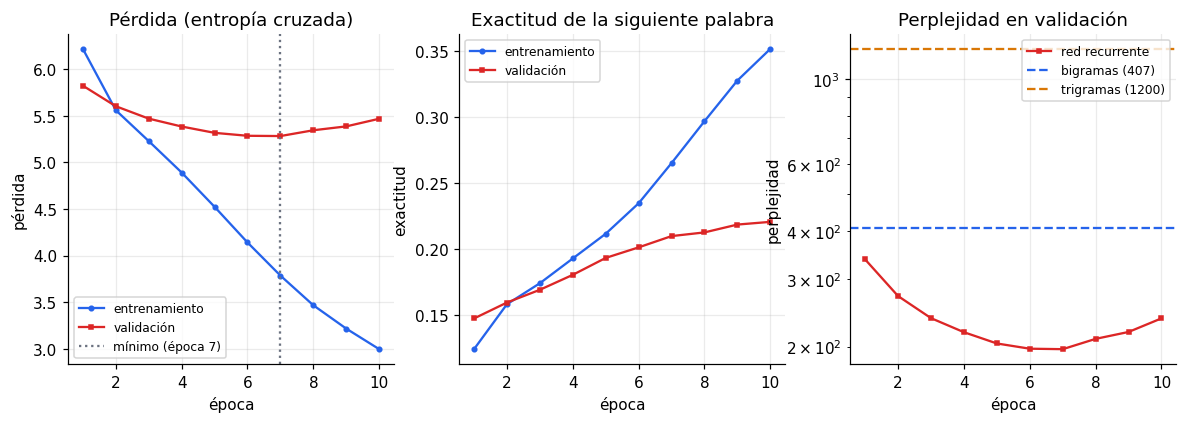

,perplejidad en validación
"bigramas (k=0,1)",407.2
"trigramas (k=0,1)",1199.9
red recurrente (mejor época),196.8


In [10]:
epocas = np.arange(1, len(h["loss"]) + 1)
fig, ejes = plt.subplots(1, 3, figsize=(13, 3.9))
ejes[0].plot(epocas, h["loss"], "o-", color=AZUL, ms=3, label="entrenamiento")
ejes[0].plot(epocas, h["val_loss"], "s-", color=ROJO, ms=3, label="validación")
ejes[0].axvline(epoca_mejor + 1, color=GRIS, ls=":", label=f"mínimo (época {epoca_mejor + 1})")
ejes[0].set(title="Pérdida (entropía cruzada)", xlabel="época", ylabel="pérdida"); ejes[0].legend(fontsize=8)
ejes[1].plot(epocas, h["accuracy"], "o-", color=AZUL, ms=3, label="entrenamiento")
ejes[1].plot(epocas, h["val_accuracy"], "s-", color=ROJO, ms=3, label="validación")
ejes[1].set(title="Exactitud de la siguiente palabra", xlabel="época", ylabel="exactitud"); ejes[1].legend(fontsize=8)
ejes[2].plot(epocas, np.exp(h["val_loss"]), "s-", color=ROJO, ms=3, label="red recurrente")
ejes[2].axhline(ppl_bi, color=AZUL, ls="--", label=f"bigramas ({ppl_bi:.0f})")
ejes[2].axhline(ppl_tri, color=NARANJA, ls="--", label=f"trigramas ({ppl_tri:.0f})")
ejes[2].set(title="Perplejidad en validación", xlabel="época", ylabel="perplejidad", yscale="log")
ejes[2].legend(fontsize=8)
guardar_figura("fig06_03_lstm_entrenamiento")
resumen_ppl = pd.Series({
    "bigramas (k=0,1)": ppl_bi, "trigramas (k=0,1)": ppl_tri,
    "red recurrente (mejor época)": float(np.exp(h["val_loss"][epoca_mejor])),
}, name="perplejidad en validación")
display(resumen_ppl.round(1).to_frame())

**Análisis.** La red alcanza una perplejidad de **196,8** en validación, frente a 407,2 de los
bigramas y 1.199,9 de los trigramas: una reducción del 51,7 % respecto a la mejor línea base con el mismo
vocabulario y la misma partición. La explicación es la generalización por representación distribuida: el
*embedding* coloca *ministro*, *presidente* y *portavoz* en vecindades parecidas, así que un contexto nunca visto
con una de ellas se beneficia de lo aprendido con las otras. El modelo de n-gramas no tiene esa vía: para él son
tres símbolos sin relación.

Las curvas también marcan el límite del ejercicio. La pérdida de entrenamiento sigue bajando sin freno hasta la
época 10, mientras la de validación toca su mínimo en la época **7** y luego sube: con
48.510 ejemplos y 1.408.905 parámetros el sobreajuste llega pronto, y solo el *dropout* y la parada
temprana lo contienen. Por eso el entrenamiento restaura los pesos de la mejor época: sin ese paso, las
generaciones de la sección siguiente se harían con una red que ya ha memorizado el corpus (su pérdida de
validación sube a 5,47, equivalente a una perplejidad de 236,9, un 20 % peor que la mejor).
La exactitud de la siguiente palabra se queda en 21,0 % en validación, una
cifra que **no debe leerse como un fracaso**: predecir exactamente la siguiente palabra de una noticia es
intrínsecamente ambiguo (tras *«el presidente del»* caben decenas de continuaciones correctas), y por eso la
perplejidad —que premia asignar probabilidad alta a la palabra correcta aunque no sea la más probable— es la
métrica adecuada.

Una observación metodológica sobre la arquitectura del laboratorio de clase: el `Bidirectional(LSTM)` **no es la
capa correcta para un modelo de lenguaje causal**, porque la pasada de derecha a izquierda solo ve el relleno a la
izquierda de la secuencia y no aporta información futura real. Se conserva por fidelidad al laboratorio, pero en
un modelo de generación estricto debería ser un `LSTM` unidireccional.

### 2.3 Comparación de generaciones: temperatura, top-k y búsqueda voraz

La misma distribución de probabilidad genera textos muy distintos según cómo se elija la palabra:

- **Búsqueda voraz (*greedy*)**: se toma siempre la palabra más probable. Determinista y, como se verá, propensa
  a bucles.
- **Muestreo con temperatura $T$**: se reescalan los logaritmos de las probabilidades, $p_i' \propto p_i^{1/T}$.
  Con $T < 1$ la distribución se agudiza (se acerca al voraz); con $T > 1$ se aplana (más sorpresa, menos
  coherencia).
- **Top-k**: se conservan solo las $k$ palabras más probables y se renormaliza, lo que elimina la cola de
  candidatos absurdos que el muestreo con temperatura alta puede seleccionar (Holtzman et al., 2020).

Se generan continuaciones de tres semillas —*El Gobierno*, *La policía detuvo*, *El Real Madrid*— con ambos
modelos y las cinco estrategias, y se miden **distinct-1** y **distinct-2** (proporción de unigramas y bigramas
distintos: diversidad) y la **tasa de repetición de trigramas** dentro de cada texto (degeneración).

In [11]:
SEMILLAS = ["El Gobierno", "La policía detuvo", "El Real Madrid"]
ESTRATEGIAS = [
    ("voraz (greedy)", dict(greedy=True)),
    ("T = 0,2", dict(temperatura=0.2)),
    ("T = 0,7", dict(temperatura=0.7)),
    ("T = 1,2", dict(temperatura=1.2)),
    ("top-k = 10, T = 1,0", dict(temperatura=1.0, top_k=10)),
]
# 40 palabras: la degeneración por repetición solo se manifiesta en textos largos.
N_PALABRAS, REPETICIONES = 40, 2

generaciones = []
for nombre, opciones in ESTRATEGIAS:
    for semilla in SEMILLAS:
        for r in range(1 if opciones.get("greedy") else REPETICIONES):
            rng = np.random.default_rng(SEED + r)
            generaciones.append({
                "modelo": "trigramas", "estrategia": nombre, "semilla": semilla,
                "texto": trigramas.generar(semilla, N_PALABRAS, rng=rng, **opciones),
            })
            generaciones.append({
                "modelo": "red recurrente", "estrategia": nombre, "semilla": semilla,
                "texto": generar_con_red(red, tokenizador, semilla, N_PALABRAS, MAXLEN,
                                         rng=np.random.default_rng(SEED + r), **opciones),
            })
gen = pd.DataFrame(generaciones)
print("Generaciones producidas:", len(gen))
display(gen[(gen.estrategia == "T = 0,7")].drop_duplicates(["modelo", "semilla"])[["modelo", "semilla", "texto"]])

Generaciones producidas: 54


,modelo,semilla,texto
18,trigramas,El Gobierno,el gobierno le el según el acuerdo presupuestario para la presentación de los diputado...
19,red recurrente,El Gobierno,el gobierno colombiano se lesionó a la armonía cita y el director del estudio hasta el...
22,trigramas,La policía detuvo,la policía detuvo a un posible once inicial en el colegio de abogados de vizcaya en la...
23,red recurrente,La policía detuvo,la policía detuvo a los mossos d'esquadra de andalucía sociales alvarez se va a disput...
26,trigramas,El Real Madrid,el real madrid vicente del bosque técnico del primer
27,red recurrente,El Real Madrid,el real madrid hizo a años a la toma en puntos de los ciudadanos con un escrito por la...


In [12]:
# Ejemplos contrastados: el voraz y la temperatura alta, que son los dos extremos del problema.
for nombre in ["voraz (greedy)", "T = 1,2"]:
    print("=" * 100); print(nombre.upper())
    for _, fila in gen[gen.estrategia == nombre].drop_duplicates(["modelo", "semilla"]).iterrows():
        print(f"[{fila.modelo:>15}] {fila.texto}")

VORAZ (GREEDY)
[      trigramas] el gobierno vasco sabin
[ red recurrente] el gobierno de la asociación de la junta de la junta de la consejería de la provincia de la provincia de la universidad de la celebración de la ciudad de la celebración de la primera jornada de la junta de la junta
[      trigramas] la policía detuvo esta madrugada a tres personas resultaron heridas por una presunta estafa y que está en la que se celebrará en la que se celebrará en la que se celebrará en la que se celebrará en la que se celebrará en
[ red recurrente] la policía detuvo a la junta de la junta de la junta de la celebración de la final de la provincia de la celebración de la ciudad de la celebración de la celebración de la ciudad de la primera jornada de la junta
[      trigramas] el real madrid que no es nuevo líder provisional de los
[ red recurrente] el real madrid ha informado hoy a efe que el presidente del gobierno josé maría aznar y el presidente del pp en la sesión de la sesión de la sesión 

,modelo,estrategia,distinct_1,distinct_2,repeticion_bigramas,repeticion_trigramas,longitud
4,red recurrente,voraz (greedy),0.289,0.432,0.456,0.320,42.7
0,red recurrente,"T = 0,2",0.277,0.496,0.284,0.139,42.7
1,red recurrente,"T = 0,7",0.477,0.824,0.048,0.000,42.7
2,red recurrente,"T = 1,2",0.645,0.956,0.004,0.000,42.7
3,red recurrente,"top-k = 10, T = 1,0",0.434,0.792,0.060,0.004,42.7
9,trigramas,voraz (greedy),0.569,0.636,0.364,0.365,19.3
5,trigramas,"T = 0,2",0.478,0.708,0.154,0.137,22.7
6,trigramas,"T = 0,7",0.472,0.783,0.109,0.053,24.0
7,trigramas,"T = 1,2",0.627,0.946,0.000,0.000,25.5
8,trigramas,"top-k = 10, T = 1,0",0.598,0.897,0.026,0.000,20.3


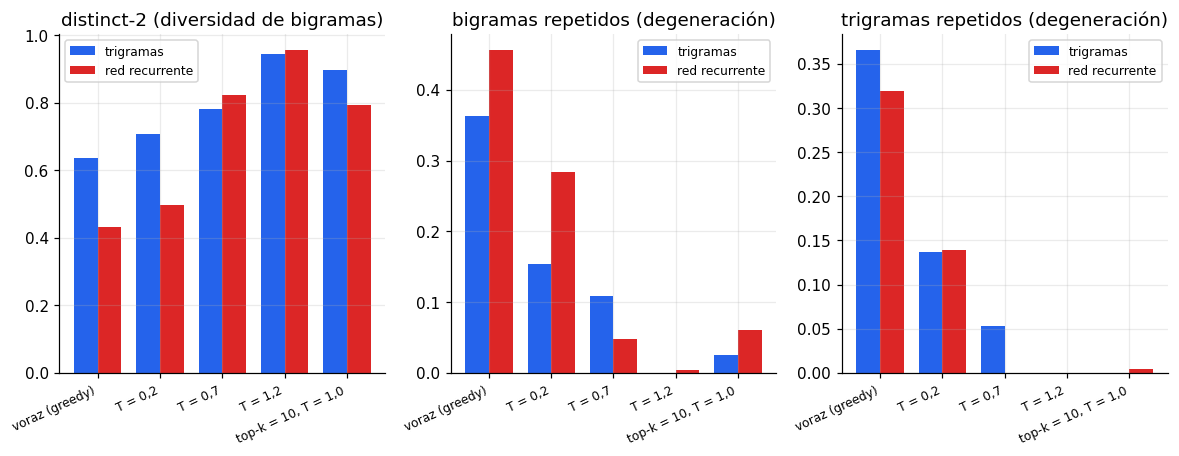

In [13]:
resumen_gen = (gen.groupby(["modelo", "estrategia"])
               .agg(distinct_1=("texto", lambda s: distinct_n(list(s), 1)),
                    distinct_2=("texto", lambda s: distinct_n(list(s), 2)),
                    repeticion_bigramas=("texto", lambda s: tasa_repeticion(list(s), 2)),
                    repeticion_trigramas=("texto", lambda s: tasa_repeticion(list(s), 3)),
                    longitud=("texto", lambda s: longitud_media(list(s))))
               .reset_index())
orden = [n for n, _ in ESTRATEGIAS]
resumen_gen["estrategia"] = pd.Categorical(resumen_gen.estrategia, orden, ordered=True)
resumen_gen = resumen_gen.sort_values(["modelo", "estrategia"])
METRICAS["generacion"] = {"tabla": resumen_gen.round(4).to_dict("records")}
display(resumen_gen.style.format({"distinct_1": "{:.3f}", "distinct_2": "{:.3f}",
                                  "repeticion_bigramas": "{:.3f}",
                                  "repeticion_trigramas": "{:.3f}", "longitud": "{:.1f}"}))

fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
x = np.arange(len(orden)); ancho = 0.38
for i, (modelo, color) in enumerate((("trigramas", AZUL), ("red recurrente", ROJO))):
    sub = resumen_gen[resumen_gen.modelo == modelo].set_index("estrategia").reindex(orden)
    ejes[0].bar(x + (i - 0.5) * ancho, sub.distinct_2, ancho, color=color, label=modelo)
    ejes[1].bar(x + (i - 0.5) * ancho, sub.repeticion_bigramas, ancho, color=color, label=modelo)
    ejes[2].bar(x + (i - 0.5) * ancho, sub.repeticion_trigramas, ancho, color=color, label=modelo)
for eje, titulo in zip(ejes, ["distinct-2 (diversidad de bigramas)", "bigramas repetidos (degeneración)",
                              "trigramas repetidos (degeneración)"]):
    eje.set(title=titulo, xticks=x); eje.set_xticklabels(orden, rotation=25, ha="right", fontsize=8)
    eje.legend(fontsize=8)
guardar_figura("fig06_04_temperatura_diversidad")

**Análisis.** Los tres paneles reproducen el fenómeno que describen Holtzman et al. (2020) para modelos mucho
mayores:

- La **búsqueda voraz degenera, y de forma masiva**. En la red recurrente, el 45,6 % de los bigramas y el
  32,0 % de los trigramas generados con búsqueda voraz son repeticiones dentro del mismo texto, frente al
  0,0 % de trigramas con $T = 0{,}7$. El texto lo muestra sin ambigüedad: *«el gobierno de la asociación de
  la junta de la junta de la consejería de la provincia de la provincia…»*. Una vez que el modelo entra en un
  estado cuya palabra más probable lo devuelve al mismo estado, nada rompe el ciclo, porque la elección es
  determinista. La búsqueda voraz no falla por elegir palabras improbables, sino por elegir **siempre** la más
  probable: maximizar la probabilidad palabra a palabra no maximiza la calidad del texto. Esa es exactamente la
  tesis de Holtzman et al. (2020), y se reproduce aquí con un modelo cuatro órdenes de magnitud más pequeño.
- La **temperatura controla el compromiso entre coherencia y diversidad**. Con $T = 0{,}2$ la red sigue atrapada
  en el bucle (distinct-2 de 0,496 y 13,9 % de trigramas repetidos), porque agudizar la distribución la
  acerca al comportamiento voraz. Con $T = 1{,}2$ el distinct-2 sube a 0,956 y la repetición desaparece, pero
  el texto pierde el sentido: *«el gobierno natural del pse-ee andaluz el aman a recibir en millones de pertenecer
  a polo»*, con errores de concordancia y de categoría gramatical que el modelo no comete a temperatura media. El
  punto útil está en medio: con $T = 0{,}7$ hay diversidad (0,824) y ningún trigrama repetido.
- El **top-k recorta la cola en lugar de reescalar toda la distribución**. Con $k = 10$ y $T = 1{,}0$ la red
  mantiene un distinct-2 de 0,792 con una tasa de repetición de trigramas de 0,4 % y produce las
  secuencias más legibles del conjunto (*«el gobierno foral de años ha presentado mañana martes una que se
  celebrará…»*). Es la corrección más eficaz de las tres: elimina los candidatos absurdos sin tener que elegir
  entre bucle y sinsentido.

La comparación entre modelos añade dos matices. Primero, **los trigramas parecen más diversos** en distinct-1,
pero esa diversidad es engañosa: proviene de copiar literalmente fragmentos del corpus de entrenamiento —un
contexto con una única continuación observada, que es el 73,2 % de los casos, reproduce la noticia original
palabra por palabra— y no de haber aprendido nada generalizable; su búsqueda voraz también degenera
(36,5 % de trigramas repetidos: *«en la que se celebrará en la que se celebrará en…»*). Segundo, los
trigramas **se agotan antes**: su longitud media con búsqueda voraz es de 19,3 palabras frente a las
42,7 de la red, porque llegan a un contexto cuya continuación más probable es el final de la línea y se
detienen. La red produce texto menos literal y sintácticamente más plausible (concordancias de género y número,
preposiciones correctas), pero su contenido es vago: nombra instituciones y verbos de agencia sin hechos detrás.
Ninguno de los dos, con 57.172 palabras de entrenamiento, produce una noticia que un editor aceptaría.

## 3. Generación de texto usando un LLM

Este tema es distinto del anterior, y la diferencia no es de tamaño sino de **método**.

| | Modelo entrenado desde cero (sección 2) | Modelo grande de lenguaje instruido |
|---|---|---|
| Datos | El corpus de la tarea (57.172 palabras) | Billones de tokens de texto general, ya consumidos en el preentrenamiento |
| Qué se ajusta | Todos los parámetros, con descenso de gradiente | **Nada**: se cambia la entrada, no el modelo |
| Coste por tarea nueva | Un entrenamiento completo | Escribir una instrucción |
| Conocimiento del mundo | Solo lo que aparece en el corpus | Lo adquirido en el preentrenamiento |
| Interfaz | `modelo.fit(X, y)` | Texto: una instrucción en lenguaje natural |

El hallazgo de Brown et al. (2020) es precisamente que, a partir de cierta escala, un modelo de lenguaje resuelve
tareas nuevas **sin actualizar sus pesos**, solo condicionando la generación con una instrucción. Las tres
estrategias que se usan aquí son:

- **Zero-shot**: la instrucción describe la tarea y no incluye ejemplos («*Escribe un titular de como máximo doce
  palabras para esta noticia*»). Funciona porque el preentrenamiento ya contiene millones de pares
  noticia-titular, y la instrucción sirve para localizar ese comportamiento.
- **Few-shot** (*in-context learning*): la instrucción incluye 2-5 ejemplos resueltos. No hay entrenamiento: los
  ejemplos son contexto, y el modelo induce de ellos el formato y el estilo. Es la vía para imponer una
  convención concreta —el patrón «SUJETO + VERBO EN PRESENTE + COMPLEMENTO» de un titular de agencia— que sería
  difícil describir con palabras.
- **Cadena de pensamiento** (*chain of thought*): se pide razonar por pasos antes de responder. Al obligar al
  modelo a escribir el razonamiento, ese razonamiento entra en el contexto de las palabras siguientes y condiciona
  la respuesta final; ayuda cuando la tarea exige decidir algo antes de redactar (qué es informativamente central,
  qué respeta la presunción de inocencia, qué elementos sobran de un texto).

### 3.1 Nota de transparencia sobre la ejecución

> **Este entorno no tiene acceso al repositorio de modelos (`huggingface.co` está bloqueado) ni a claves de API**,
> de modo que **en este notebook no se ejecuta ninguna llamada a un modelo grande de lenguaje**. Para no sustituir
> el experimento por una descripción vacía se procede en dos partes:
>
> 1. **El código completo y comentado se incluye sin ejecutar** (sección 3.2), tanto en la variante local con
>    `transformers` —la que funcionaría en Google Colab, donde `huggingface.co` sí es accesible— como en la
>    variante por API. Está escrito para ejecutarse tal cual: lo único que falta es la red.
> 2. **Las salidas del experimento se registran en `datos/generacion_llm.csv`** (sección 3.3). Esas salidas las
>    produjo **Claude Opus 5 (Anthropic) el 27 de septiembre de 2026 en modo conversacional**, no una llamada
>    lanzada desde este notebook. El CSV es, por tanto, el **registro documental del experimento**: permite medir
>    y comparar las salidas con las de la sección 2, pero **no es reproducible ejecutando el notebook**, y esa es
>    exactamente una de las limitaciones que la propia sección analiza (ver 3.4).

### 3.2 Código de referencia (no ejecutado en este entorno)

**Variante A — modelo abierto en local o en Colab, con `transformers`.** Descarga los pesos de un modelo
instruido y genera con los mismos parámetros de muestreo que se estudiaron en la sección 2.3.

```python
# Requiere acceso a huggingface.co. En Colab: !pip install -q transformers accelerate
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODELO = "Qwen/Qwen2.5-1.5B-Instruct"   # modelo instruido, pequeño, con buen español

tok = AutoTokenizer.from_pretrained(MODELO)
modelo = AutoModelForCausalLM.from_pretrained(
    MODELO,
    torch_dtype=torch.float16,           # en CPU usar torch.float32
    device_map="auto",
)

def generar_llm(instruccion: str, max_tokens: int = 160, temperatura: float = 0.7,
                top_p: float = 0.9) -> str:
    # Aplica la plantilla de conversación del modelo y devuelve solo la respuesta.
    mensajes = [
        {"role": "system", "content": "Eres un redactor de la agencia EFE. Escribes en español "
                                      "neutro, sin adjetivación valorativa y sin inventar datos."},
        {"role": "user", "content": instruccion},
    ]
    # La plantilla inserta los marcadores de turno que el modelo vio durante su ajuste por instrucciones.
    entrada = tok.apply_chat_template(mensajes, add_generation_prompt=True, return_tensors="pt")
    entrada = entrada.to(modelo.device)
    with torch.no_grad():
        salida = modelo.generate(
            entrada,
            max_new_tokens=max_tokens,
            do_sample=True,              # muestreo, como en la sección 2.3
            temperature=temperatura,     # mismo parámetro, misma interpretación
            top_p=top_p,                 # núcleo (nucleus): variante del top-k de Holtzman et al. (2020)
            repetition_penalty=1.05,     # contrapeso explícito a la degeneración por repetición
            pad_token_id=tok.eos_token_id,
        )
    return tok.decode(salida[0][entrada.shape[-1]:], skip_special_tokens=True).strip()


# Las tres estrategias son únicamente tres formas de redactar `instruccion`.
noticia = ("La balanza comercial de Chile registró al 30 de abril pasado un déficit de 32 millones "
           "de dólares, producto de exportaciones por 1.316 millones e importaciones por 1.348 "
           "millones, informó hoy el Banco Central.")

zero_shot = f"Escribe un titular de agencia de como máximo doce palabras para esta noticia.\n\n«{noticia}»"

few_shot = (
    "Escribe titulares con el patrón SUJETO + VERBO EN PRESENTE + COMPLEMENTO.\n\n"
    "Noticia: «Cajalón inauguró hoy su nueva oficina en Nájera, la décima en La Rioja.»\n"
    "Titular: Cajalón abre en Nájera su décima oficina en La Rioja\n\n"
    "Noticia: «Dos profesoras de la Politécnica de Huesca criticaron la descentralización "
    "de la Universidad de Zaragoza.»\n"
    "Titular: Dos profesoras de Huesca critican la descentralización de la Universidad de Zaragoza\n\n"
    f"Noticia: «{noticia}»\nTitular:"
)

cadena_de_pensamiento = (
    "Razona en tres pasos antes de responder: (1) identifica el dato central; (2) decide qué cifras "
    "deben aparecer en el titular; (3) escribe el titular. Marca el razonamiento con «Razonamiento:» "
    f"y la respuesta con «Titular:».\n\n«{noticia}»"
)

for nombre, instruccion in [("zero-shot", zero_shot), ("few-shot", few_shot),
                            ("cadena de pensamiento", cadena_de_pensamiento)]:
    print(nombre, "->", generar_llm(instruccion))
```

**Variante B — API de un proveedor (Anthropic; el patrón con OpenAI es idéntico).** No descarga pesos: envía la
instrucción y recibe el texto. Es la vía que se usaría en producción, y la que introduce la dependencia de un
tercero que se discute en 3.4.

```python
# Requiere la variable de entorno ANTHROPIC_API_KEY. pip install anthropic
import os, anthropic

cliente = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

def generar_api(instruccion: str, temperatura: float = 0.7, max_tokens: int = 300) -> str:
    respuesta = cliente.messages.create(
        model="claude-opus-4-20250514",
        max_tokens=max_tokens,
        temperature=temperatura,
        system=("Eres un redactor de la agencia EFE. Escribes en español neutro, sin adjetivación "
                "valorativa y sin inventar datos que no estén en el texto de partida."),
        messages=[{"role": "user", "content": instruccion}],
    )
    return respuesta.content[0].text.strip()


# Equivalente con OpenAI:
# from openai import OpenAI
# cliente = OpenAI()
# respuesta = cliente.chat.completions.create(
#     model="gpt-4o", temperature=0.7,
#     messages=[{"role": "system", "content": "..."}, {"role": "user", "content": instruccion}])
# texto = respuesta.choices[0].message.content

registros = []
for id_doc, tarea, estrategia, instruccion in casos:          # `casos` = la batería de prompts
    registros.append({"id_doc": id_doc, "tarea": tarea, "estrategia": estrategia,
                      "prompt": instruccion, "salida": generar_api(instruccion)})
pd.DataFrame(registros).to_csv(RAIZ / "datos" / "generacion_llm.csv", index=False)
```

El punto que conviene retener de los dos bloques: **no aparece `fit`, ni `loss`, ni épocas**. Todo el diseño del
experimento está en el texto de `instruccion` y en los parámetros de muestreo, que son los mismos
—temperatura, top-k/top-p— que se midieron en la sección 2.3 sobre un modelo propio.

### 3.3 Registro del experimento de prompting

`datos/generacion_llm.csv` contiene 10 registros sobre noticias reales del corpus EFE, con las cuatro tareas
(continuación, titular, resumen en una frase y reescritura) y las tres estrategias. La columna `id_doc` remite al
identificador de la noticia en el corpus, de modo que cada salida se puede confrontar con su texto de origen.

In [14]:
llm = pd.read_csv(RAIZ / "datos" / "generacion_llm.csv")
print("Registros:", len(llm))
display(pd.crosstab(llm.tarea, llm.estrategia, margins=True))
display(llm[["id_doc", "tarea", "estrategia", "salida"]].head(10))

Registros: 10


estrategia,cadena de pensamiento,few-shot,zero-shot,All
tarea,,,,
continuación,1,1,1,3
reescritura,1,0,1,2
resumen en una frase,0,1,1,2
titular,1,1,1,3
All,3,3,4,10


,id_doc,tarea,estrategia,salida
0,17,continuación,zero-shot,"Las portadas coinciden en destacar la solidez del equipo blanco, que resolvió el parti..."
1,805,continuación,few-shot,«El equipo español confirmó que el corredor sufre rotura de radio y escafoides en el b...
2,420,continuación,cadena de pensamiento,Razonamiento: (1) Quien propone es el grupo municipal EU-Els Verds y lo que propone es...
3,238,titular,zero-shot,La balanza comercial chilena cierra abril con un déficit de 32 millones de dólares
4,640,titular,few-shot,Cajalón abre en Nájera su décima oficina en La Rioja
5,300,titular,cadena de pensamiento,"Razonamiento: el hecho noticioso del día es la declaración de un testigo en el juicio,..."
6,900,resumen en una frase,zero-shot,Dos profesoras de la Politécnica de Huesca atribuyeron ante la comisión universitaria ...
7,533,resumen en una frase,few-shot,«La Concejalía de Juventud cierra mañana por la noche el plazo de entrega de maquetas ...
8,712,reescritura,zero-shot,El novillero salmantino Javier Castaño salió a hombros por la Puerta Grande de la plaz...
9,51,reescritura,cadena de pensamiento,Razonamiento: la descripción física («escultural jovencita de ojos y cabellos castaños...


In [15]:
# Un caso completo, para que se vea la instrucción entera y su salida.
caso = llm[llm.estrategia == "cadena de pensamiento"].iloc[1]
print("TAREA:", caso.tarea, "| ESTRATEGIA:", caso.estrategia, "| NOTICIA:", caso.id_doc)
print("\n--- PROMPT ---\n" + caso.prompt)
print("\n--- SALIDA (Claude Opus 5, 27/09/2026, modo conversacional) ---\n" + caso.salida)
print("\n--- NOTICIA ORIGINAL DEL CORPUS ---\n" + quitar_cabecera_agencia(corpus.texto[caso.id_doc])[:420] + " …")

TAREA: titular | ESTRATEGIA: cadena de pensamiento | NOTICIA: 300

--- PROMPT ---
Para esta noticia de tribunales, razona primero qué elemento es informativamente central y cuál es accesorio, considera el respeto a la presunción de inocencia y solo después propón el titular. Formato: «Razonamiento:» y «Titular:».

«La vinculación de la muerte del asesor fiscal Francisco Javier Sánchez Bocanegra con un hombre con el que había mantenido supuestamente relaciones sorprendió a sus amigos. Según declaró hoy un amigo durante el juicio que se celebra en la Audiencia Provincial de Málaga contra el acusado como presunto autor del crimen.»

--- SALIDA (Claude Opus 5, 27/09/2026, modo conversacional) ---
Razonamiento: el hecho noticioso del día es la declaración de un testigo en el juicio, no la vida privada de la víctima, que es accesoria y además está atribuida a un supuesto. El acusado es presunto autor, así que el titular debe evitar afirmar su culpabilidad y debe atribuir lo dicho a la fuente

,generador,distinct_1,distinct_2,repeticion_trigramas,longitud,fuera_del_vocabulario_5k
0,trigramas (top-k = 10),0.598,0.897,0.000,20.3,0.000
1,red recurrente (top-k = 10),0.434,0.792,0.004,42.7,0.000
2,LLM instruido (registro),0.543,0.919,0.006,50.3,0.165


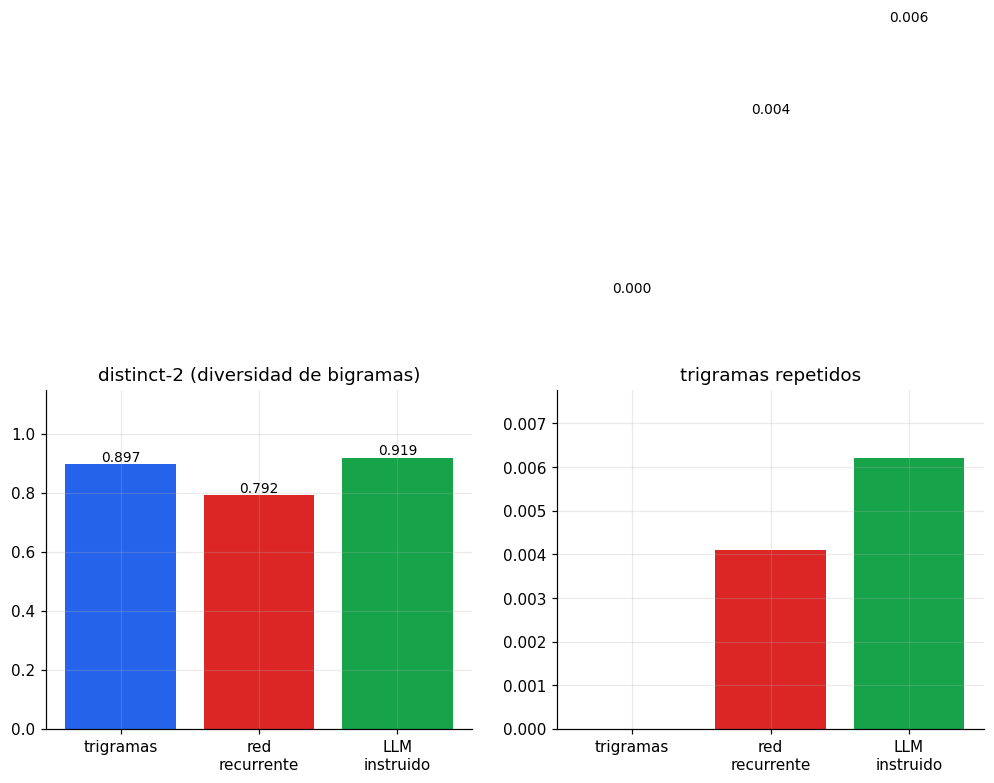

In [16]:
# Métricas comparables con las de la sección 2.3: se miden sobre el mismo tipo de objeto (texto generado).
salidas_llm = llm.salida.tolist()
mejor_red = resumen_gen[(resumen_gen.modelo == "red recurrente") & (resumen_gen.estrategia == "top-k = 10, T = 1,0")]
mejor_tri = resumen_gen[(resumen_gen.modelo == "trigramas") & (resumen_gen.estrategia == "top-k = 10, T = 1,0")]

comparacion = pd.DataFrame([
    {"generador": "trigramas (top-k = 10)", "distinct_1": float(mejor_tri.distinct_1.iloc[0]),
     "distinct_2": float(mejor_tri.distinct_2.iloc[0]),
     "repeticion_trigramas": float(mejor_tri.repeticion_trigramas.iloc[0]),
     "longitud": float(mejor_tri.longitud.iloc[0])},
    {"generador": "red recurrente (top-k = 10)", "distinct_1": float(mejor_red.distinct_1.iloc[0]),
     "distinct_2": float(mejor_red.distinct_2.iloc[0]),
     "repeticion_trigramas": float(mejor_red.repeticion_trigramas.iloc[0]),
     "longitud": float(mejor_red.longitud.iloc[0])},
    {"generador": "LLM instruido (registro)", "distinct_1": distinct_n(salidas_llm, 1),
     "distinct_2": distinct_n(salidas_llm, 2), "repeticion_trigramas": tasa_repeticion(salidas_llm, 3),
     "longitud": longitud_media(salidas_llm)},
])
# Proporción de tokens fuera del vocabulario de 5.000 palabras: mide cuánto léxico usa cada generador
# más allá de lo que el corpus de entrenamiento podía enseñar.
def fuera_de_vocabulario(textos):
    palabras = [p for t in textos for p in tokenizador.tokenizar(t)]
    return sum(1 for p in palabras if p not in vocab_recortado) / len(palabras)

comparacion["fuera_del_vocabulario_5k"] = [
    fuera_de_vocabulario(gen[(gen.modelo == "trigramas") & (gen.estrategia == "top-k = 10, T = 1,0")].texto.tolist()),
    fuera_de_vocabulario(gen[(gen.modelo == "red recurrente") & (gen.estrategia == "top-k = 10, T = 1,0")].texto.tolist()),
    fuera_de_vocabulario(salidas_llm),
]
METRICAS["llm"] = {
    "registros": len(llm),
    "tareas": sorted(llm.tarea.unique().tolist()),
    "estrategias": sorted(llm.estrategia.unique().tolist()),
    "comparacion": comparacion.round(4).to_dict("records"),
    "procedencia": "Claude Opus 5 (Anthropic), 27/09/2026, modo conversacional; no ejecutado desde el notebook",
}
display(comparacion.style.format({"distinct_1": "{:.3f}", "distinct_2": "{:.3f}",
                                  "repeticion_trigramas": "{:.3f}", "longitud": "{:.1f}",
                                  "fuera_del_vocabulario_5k": "{:.3f}"}))

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
etiquetas = ["trigramas", "red\nrecurrente", "LLM\ninstruido"]
colores = [AZUL, ROJO, VERDE]
for eje, columna, titulo in zip(ejes, ["distinct_2", "repeticion_trigramas"],
                               ["distinct-2 (diversidad de bigramas)", "trigramas repetidos"]):
    barras = eje.bar(etiquetas, comparacion[columna], color=colores)
    for b, v in zip(barras, comparacion[columna]):
        eje.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
    eje.set(title=titulo, ylim=(0, max(comparacion[columna]) * 1.25))
guardar_figura("fig06_05_llm_vs_entrenado")

**Análisis.** Las métricas de superficie son las **menos** informativas de la comparación, y conviene decirlo
antes de leerlas: distinct-2 y la tasa de repetición miden diversidad, no calidad, y el LLM no gana por
diversidad —su distinct-2 es 0,919, frente a 0,792 de la red— sino por todo lo que esas métricas no
capturan.

1. **Coherencia y estructura.** Las salidas del LLM son oraciones completas, con concordancia, puntuación y
   progresión temática; la red recurrente produce secuencias localmente plausibles que no llegan a constituir una
   oración con sentido, y los trigramas copian fragmentos que se contradicen entre sí. La diferencia no está en la
   arquitectura sino en la escala de datos: el LLM ha visto órdenes de magnitud más texto que las
   57.172 palabras de la sección 2.
2. **Control por instrucción.** Es la diferencia práctica decisiva. Con la red hay una sola palanca —la semilla— y
   dos parámetros de muestreo; con el LLM se especifica la tarea («titular de doce palabras»), el formato
   («Razonamiento:» / «Titular:») y restricciones de contenido («sin verbos en futuro», «elimina la descripción
   física», «respeta la presunción de inocencia»), y todo ello **sin reentrenar**. Cambiar de tarea cuesta
   reescribir un párrafo, no un entrenamiento.
3. **Conocimiento del mundo.** La reescritura de la crónica taurina exige saber qué significa «salir a hombros
   por la Puerta Grande»; el resumen sobre Huesca exige entender la relación entre campus y titulaciones. Nada de
   eso está aprendible a partir de las dos primeras oraciones de 998 noticias, y el 16,5 % del léxico de las
   salidas del LLM queda fuera del vocabulario de 5.000 palabras con el que se entrenaron los modelos de la
   sección 2: literalmente usa palabras que el otro modelo no puede producir.
4. **La estrategia importa y es observable.** Los tres registros *zero-shot* son correctos pero genéricos; los
   *few-shot* reproducen el patrón sintáctico de los ejemplos (los dos titulares siguen el molde
   SUJETO + VERBO EN PRESENTE + COMPLEMENTO sin que se describa la regla); los de cadena de pensamiento son los
   únicos en los que se puede **auditar la decisión** —en el caso del juicio de Málaga el razonamiento explicita
   que la vida privada de la víctima es accesoria y que el acusado es presunto autor, y el titular resultante lo
   refleja—. Ese rastro es lo que hace la estrategia valiosa en tareas con criterio editorial o legal.

**Riesgos, y son serios.**

- **Invención de datos.** El modelo produce texto plausible con la misma fluidez tenga o no respaldo en la fuente.
  En el registro 2 (*few-shot*) la continuación acierta las lesiones del ciclista porque estaban en el corpus,
  pero nada en el mecanismo distingue «recuperar» de «inventar»: la fluidez es idéntica en ambos casos. En
  periodismo eso obliga a verificar toda cifra, nombre y atribución contra la fuente, lo que reduce, pero no
  elimina, la ganancia de productividad.
- **Coste y latencia.** La red de la sección 2 se entrenó una vez en unos 90 segundos y después genera gratis
  en CPU; el LLM no cuesta entrenamiento pero cobra **por cada llamada**, y la factura crece con el volumen. Para
  una tarea fija y masiva —clasificar un millón de titulares— un modelo pequeño propio puede ser más barato.
- **Dependencia de un proveedor.** El modelo es un servicio remoto: puede cambiar de versión, subir de precio,
  restringir un uso o desaparecer, y enviarle texto implica sacarlo de la propia infraestructura, con las
  consecuencias legales que eso tenga sobre material con derechos o datos personales.
- **No reproducibilidad exacta.** Este notebook lo demuestra involuntariamente: la sección 2 se reproduce fijando
  `SEED` y vuelve a dar las mismas cifras, mientras que la sección 3 **no se puede reejecutar aquí**, y aun con
  acceso las salidas dependerían de la versión del modelo y del muestreo. El CSV es un registro fechado, no un
  experimento repetible; para un trabajo evaluable esa asimetría debe declararse, y es la razón de la nota de
  transparencia de 3.1.

## 4. Text mining sobre las 998 noticias

La minería de texto invierte la dirección del notebook: en lugar de producir lenguaje, se trata de extraer
estructura de una colección que nadie puede leer entera. Se trabaja sobre el corpus **completo** (998 noticias) y
con las decisiones del notebook 01: cabecera de agencia eliminada, lematización con spaCy, *stopwords* de NLTK sin
negaciones y, para las representaciones temáticas, solo **sustantivos, nombres propios y adjetivos** —las
categorías que nombran aquello de lo que se habla—.

In [17]:
textos_limpios = [quitar_cabecera_agencia(t) for t in corpus.texto]
nlp = cargar_spacy()  # tagger + lemmatizer; NER y parser deshabilitados por velocidad

inicio = time.time()
analizados = [[(t.lemma_.lower(), t.pos_) for t in doc if t.is_alpha]
              for doc in nlp.pipe(textos_limpios, batch_size=32, n_process=2)]
print(f"Lematización de {len(analizados)} noticias en {time.time() - inicio:.0f} s "
      f"({sum(len(d) for d in analizados):,} tokens)".replace(",", "."))

# «efe», «may» y variantes son ruido de dominio: la cabecera se elimina al principio de cada noticia,
# pero la firma de la agencia reaparece dentro del cuerpo («, 25 may (EFE)») en las notas refundidas.
RUIDO_AGENCIA = {"efe", "may", "efecom", "efeagro"}
STOP = (stopwords_nltk() - NEGACIONES) | RUIDO_AGENCIA
CATEGORIAS_TEMATICAS = {"NOUN", "PROPN", "ADJ"}

docs_lemas = [[l for l, p in d if p in CATEGORIAS_TEMATICAS and l not in STOP and len(l) > 2]
              for d in analizados]
tokens_planos = [[t.lower() for t in tokenizar(tx) if es_palabra(t)] for tx in textos_limpios]

METRICAS["mineria"] = {
    "documentos": len(corpus),
    "tokens_lematizados": int(sum(len(d) for d in analizados)),
    "tokens_tematicos": int(sum(len(d) for d in docs_lemas)),
    "vocabulario_tematico": len({w for d in docs_lemas for w in d}),
}
display(pd.Series(METRICAS["mineria"], name="valor").to_frame())

Lematización de 998 noticias en 10 s (306.494 tokens)


,valor
documentos,998
tokens_lematizados,306494
tokens_tematicos,121537
vocabulario_tematico,14699


### 4.1 N-gramas más frecuentes

Se cuentan bigramas y trigramas de dos formas: sobre el texto **con** palabras funcionales (lo que revela la
sintaxis del castellano y el ruido de formato) y sobre los **lemas de contenido** (lo que revela de qué se habla).

Bigrama «may efe»: 59 ocurrencias, puesto 6 entre los bigramas de contenido del texto crudo
Primeros bigramas de contenido del texto crudo: ['real madrid', 'informó hoy', 'hoy martes', 'sin embargo', 'secretario general', 'may efe', 'medio ambiente', 'unión europea']


bigramas (texto crudo)            bigramas (lemas de contenido)             \
                  n-grama frecuencia                       n-grama frecuencia   
0                   de la       3981                millón pesetas        203   
1                   en el       1867                millón dólares        135   
2                   en la       1618                   real madrid        109   
3                  de los       1487            secretario general         62   
4                    a la       1168                medio ambiente         59   
5                  que se       1068                 unión europea         55   
6                  de las        944                  rueda prensa         55   
7                  que el        779                    sur líbano         54   
8                  que la        616                    josé maría         52   
9                   a los        602              director general         52   
10             por ciento        589            medio comunicación         51   
11                 por el        546                liga campeones         50   

   trigramas (lemas de contenido)             
                          n-grama frecuencia  
0                josé maría aznar         30  
1            final liga campeones         29  
2            real madrid valencia         22  
3             gobierno josé maría         18  
4           banco central europeo         15  
5        presidente gobierno josé         15  
6              israelí sur líbano         13  
7           primero trimestre año         13  
8                 don juan carlos         13  
9           millón pesetas millón         13  
10            ejército sur líbano         12  
11                 sur líbano esl         11

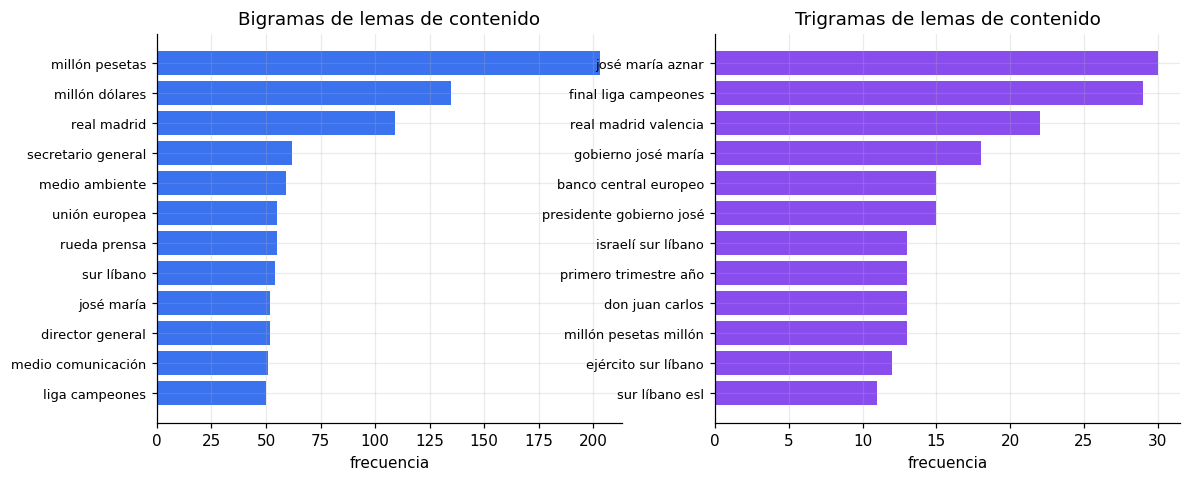

In [18]:
def contar_ngramas(documentos, n):
    conteo = Counter()
    for d in documentos:
        conteo.update(tuple(d[i:i + n]) for i in range(len(d) - n + 1))
    return conteo

bi_bruto, tri_bruto = contar_ngramas(tokens_planos, 2), contar_ngramas(tokens_planos, 3)
bi_cont, tri_cont = contar_ngramas(docs_lemas, 2), contar_ngramas(docs_lemas, 3)

def a_tabla(conteo, n_filas=12):
    return pd.DataFrame({"n-grama": [" ".join(g) for g, _ in conteo.most_common(n_filas)],
                         "frecuencia": [c for _, c in conteo.most_common(n_filas)]})

# Auditoría: ¿cuánto pesa la firma de agencia que sobrevive dentro del cuerpo de las noticias?
stop_basica = stopwords_nltk() - NEGACIONES
bi_bruto_contenido = Counter({g: c for g, c in bi_bruto.items()
                              if all(w not in stop_basica and len(w) > 2 for w in g)})
ranking_bruto = [g for g, _ in bi_bruto_contenido.most_common()]
posicion_may_efe = ranking_bruto.index(("may", "efe")) + 1
METRICAS["mineria"]["ruido_may_efe"] = {"frecuencia": int(bi_bruto_contenido[("may", "efe")]),
                                        "posicion_sin_filtrar": int(posicion_may_efe)}
print(f"Bigrama «may efe»: {bi_bruto_contenido[('may', 'efe')]} ocurrencias, "
      f"puesto {posicion_may_efe} entre los bigramas de contenido del texto crudo")
print("Primeros bigramas de contenido del texto crudo:",
      [" ".join(g) for g in ranking_bruto[:8]])

tabla_ng = pd.concat({"bigramas (texto crudo)": a_tabla(bi_bruto), "bigramas (lemas de contenido)": a_tabla(bi_cont),
                      "trigramas (lemas de contenido)": a_tabla(tri_cont)}, axis=1)
METRICAS["mineria"]["bigramas_contenido"] = a_tabla(bi_cont, 10).to_dict("records")
METRICAS["mineria"]["trigramas_contenido"] = a_tabla(tri_cont, 10).to_dict("records")
display(tabla_ng)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.6))
for eje, conteo, titulo, color in ((ejes[0], bi_cont, "Bigramas de lemas de contenido", AZUL),
                                   (ejes[1], tri_cont, "Trigramas de lemas de contenido", MORADO)):
    top = conteo.most_common(12)[::-1]
    eje.barh([" ".join(g) for g, _ in top], [c for _, c in top], color=color, alpha=0.9)
    eje.set(title=titulo, xlabel="frecuencia"); eje.tick_params(axis="y", labelsize=8.5)
guardar_figura("fig06_06_ngramas_frecuentes")

**Análisis.** Los dos conteos responden a preguntas distintas y solo el segundo es útil para la minería. Sobre
texto crudo, los bigramas más frecuentes son secuencias de palabras funcionales (*de la* con 3.981
ocurrencias, *en el*, *en la*): describen la gramática del español, no el contenido de las noticias, y confirman
por otra vía el argumento del notebook 01 para eliminar *stopwords*.

Sobre lemas de contenido aparece la agenda: **millón pesetas** (203 veces) y **millón dólares**
(135) son unidades de medida económica, *real madrid* (109) es la noticia deportiva del mes
—mayo de 2000, final de la Liga de Campeones—, y el resto son fórmulas institucionales (*secretario general*,
*rueda prensa*, *unión europea*, *director general*) más un foco geopolítico (*sur líbano*, 54 veces). Los
trigramas son más elocuentes todavía: *josé maría aznar* (30), *final liga campeones* (29),
*real madrid valencia*, *banco central europeo*, *israelí sur líbano*, *don juan carlos*. Cuatro acontecimientos
concretos y un marco institucional: eso es la agenda del mes, obtenida con dos líneas de conteo.

La auditoría de la firma de agencia confirma una decisión tomada antes del modelado: el bigrama *may efe* aparece
59 veces y ocuparía el puesto 6 entre los bigramas de contenido del texto crudo. Es
residuo de la firma de agencia en el interior de las notas refundidas: `quitar_cabecera_agencia` solo actúa sobre
el comienzo de cada documento. Por eso se añadió `{efe, may, efecom, efeagro}` a la lista de palabras vacías antes
del modelado de temas —en una primera versión de esta sección, sin ese filtro, *may efe* entraba entre los diez
bigramas de contenido más frecuentes y LDA construía un tema alrededor del ruido de formato—. El conteo de
n-gramas funciona, además de como análisis, como **auditoría del preprocesamiento**.

### 4.2 Colocaciones: información mutua puntual y log-verosimilitud

Frecuencia y asociación no son lo mismo. *informó hoy* es frecuente porque sus dos palabras lo son; *dow jones*
es raro en términos absolutos pero sus dos componentes **casi nunca aparecen por separado**. Las medidas de
asociación de NLTK (Bird et al., 2009) capturan esa diferencia:

- **PMI**: $\mathrm{PMI}(x, y) = \log_2 \dfrac{P(x, y)}{P(x)P(y)}$. Cuánto más aparecen juntas de lo esperable si
  fueran independientes. Favorece pares raros pero exclusivos, por lo que requiere un filtro de frecuencia
  mínima: sin él, cualquier par que aparezca una sola vez obtiene el PMI máximo.
- **Log-verosimilitud**: contrasta la hipótesis de independencia con un estadístico que **pondera por la
  evidencia disponible**, de modo que un par frecuente y asociado puntúa más que un par raro y exclusivo.

In [19]:
from nltk.collocations import BigramCollocationFinder, TrigramCollocationFinder
from nltk.metrics import BigramAssocMeasures, TrigramAssocMeasures

palabras_todas = [w for d in tokens_planos for w in d]
MIN_FREC = 10

buscador = BigramCollocationFinder.from_words(palabras_todas)
buscador.apply_freq_filter(MIN_FREC)                      # sin este filtro el PMI premia lo que sale una vez
buscador.apply_word_filter(lambda w: w in STOP or len(w) < 3)
medidas = BigramAssocMeasures()

comparativa = pd.DataFrame({
    "por frecuencia": [" ".join(b) for b in buscador.nbest(medidas.raw_freq, 15)],
    "por log-verosimilitud": [" ".join(b) for b in buscador.nbest(medidas.likelihood_ratio, 15)],
    "por PMI": [" ".join(b) for b in buscador.nbest(medidas.pmi, 15)],
})
display(comparativa)

buscador_tri = TrigramCollocationFinder.from_words(palabras_todas)
buscador_tri.apply_freq_filter(5)
buscador_tri.apply_word_filter(lambda w: w in STOP or len(w) < 3)
medidas_tri = TrigramAssocMeasures()
print("Trigramas por log-verosimilitud:", [" ".join(t) for t in buscador_tri.nbest(medidas_tri.likelihood_ratio, 8)])
print("Trigramas por PMI:              ", [" ".join(t) for t in buscador_tri.nbest(medidas_tri.pmi, 8)])

METRICAS["mineria"]["colocaciones"] = {
    "min_frecuencia": MIN_FREC,
    "candidatos": len(list(buscador.ngram_fd)),
    "pmi_top10": [" ".join(b) for b in buscador.nbest(medidas.pmi, 10)],
    "log_verosimilitud_top10": [" ".join(b) for b in buscador.nbest(medidas.likelihood_ratio, 10)],
}

,por frecuencia,por log-verosimilitud,por PMI
0,real madrid,real madrid,wall street
1,informó hoy,sin embargo,bellas artes
2,hoy martes,medio ambiente,intentona golpista
3,sin embargo,hoy martes,cascos azules
4,secretario general,unión europea,dow jones
5,medio ambiente,sao paulo,corín tellado
6,unión europea,secretario general,reino unido
7,josé maría,sierra leona,france telecom
8,anunció hoy,nueva york,castilla-la mancha
9,director general,informó hoy,suelo rústico


Trigramas por log-verosimilitud: ['real madrid adecco', 'estudiantes real madrid', 'según informó hoy', 'josé maría aznar', 'sierra leona frustraron', 'sao paulo brasil', 'gobierno josé maría', 'sierra leona golpe']
Trigramas por PMI:               ['emanuel dimas pimenta', 'jean claude gayssot', 'pabellón raimundo saporta', 'café azúcar cacao', 'turismo celestí alomar', 'jean pierre chevenement', 'yugoslavo slobodan milosevic', 'meteorología inm prevé']


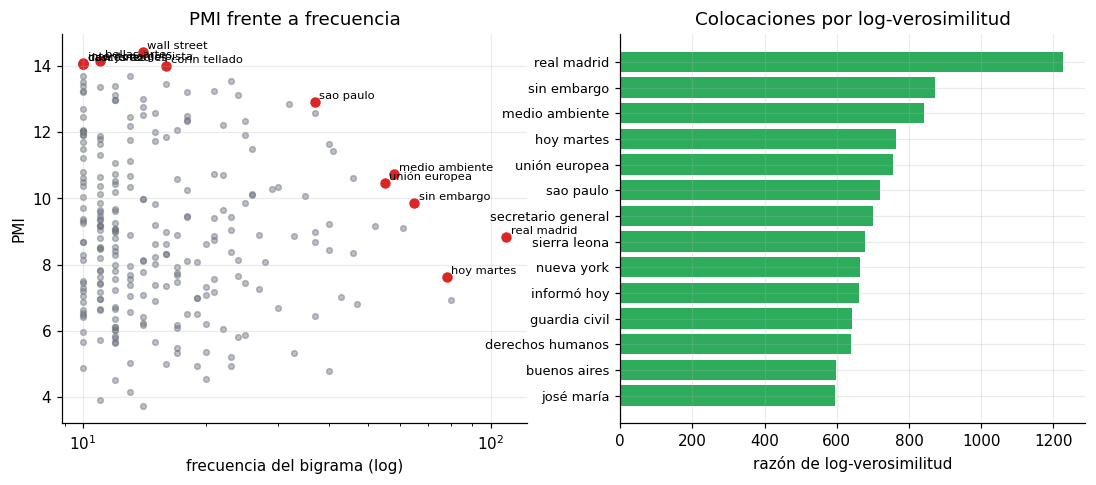

Candidatos evaluados: 259


In [20]:
# Las dos medidas puntuadas sobre los mismos candidatos, para ver qué privilegia cada una.
filas = []
for b in buscador.ngram_fd:
    if b[0] in STOP or b[1] in STOP or len(b[0]) < 3 or len(b[1]) < 3:
        continue
    if buscador.ngram_fd[b] < MIN_FREC:
        continue
    filas.append({"bigrama": " ".join(b), "frecuencia": buscador.ngram_fd[b],
                  "pmi": buscador.score_ngram(medidas.pmi, *b),
                  "log_verosimilitud": buscador.score_ngram(medidas.likelihood_ratio, *b)})
puntuaciones = pd.DataFrame(filas)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.6))
eje = ejes[0]
eje.scatter(puntuaciones.frecuencia, puntuaciones.pmi, s=14, alpha=0.45, color=GRIS)
destacados = pd.concat([puntuaciones.nlargest(6, "pmi"), puntuaciones.nlargest(6, "log_verosimilitud")])
eje.scatter(destacados.frecuencia, destacados.pmi, s=34, color=ROJO)
for _, f in destacados.iterrows():
    eje.annotate(f.bigrama, (f.frecuencia, f.pmi), fontsize=7.5, xytext=(3, 2), textcoords="offset points")
eje.set(title="PMI frente a frecuencia", xlabel="frecuencia del bigrama (log)", ylabel="PMI", xscale="log")

top_lr = puntuaciones.nlargest(14, "log_verosimilitud").iloc[::-1]
ejes[1].barh(top_lr.bigrama, top_lr.log_verosimilitud, color=VERDE, alpha=0.9)
ejes[1].set(title="Colocaciones por log-verosimilitud", xlabel="razón de log-verosimilitud")
ejes[1].tick_params(axis="y", labelsize=8.5)
guardar_figura("fig06_07_colocaciones")
print("Candidatos evaluados:", len(puntuaciones))

**Análisis.** Las tres columnas ordenan los **mismos** 259 candidatos y coinciden poco, lo que es
exactamente el punto:

- La **frecuencia** devuelve fórmulas del oficio periodístico: *informó hoy*, *hoy martes*, *anunció hoy*, *dijo
  hoy*, *según informó*. Son colocaciones reales, pero del género textual, no del contenido.
- La **log-verosimilitud** devuelve nombres y unidades con peso informativo: *real madrid*, *medio ambiente*,
  *unión europea*, *sierra leona*, *nueva york*, *buenos aires*, *derechos humanos*. Es la medida más útil como
  extractor de términos, porque exige a la vez asociación y evidencia suficiente. No es perfecta: *sin embargo* y
  *hoy martes* aparecen en sus primeros puestos, porque son también pares fijos con muchísima evidencia, y ningún
  criterio puramente estadístico distingue una locución del discurso de un término del dominio.
- El **PMI** devuelve los pares **más exclusivos**: *wall street*, *dow jones*, *bellas artes*, *cascos azules*,
  *intentona golpista*, *corín tellado*. Son unidades léxicas casi indivisibles —ninguno de sus componentes
  aparece apenas por separado en el corpus— y varias son términos que un diccionario general no contendría.

El gráfico de dispersión muestra la propiedad que obliga a filtrar: el PMI **decrece** con la frecuencia, de modo
que sin `apply_freq_filter` los primeros puestos los ocuparían pares vistos una sola vez, con PMI máximo y valor
nulo. Los trigramas lo exageran: por PMI salen nombres propios completos (*emanuel dimas pimenta*, *jean claude
gayssot*, *yugoslavo slobodan milosevic*) y por log-verosimilitud, unidades reutilizables (*josé maría aznar*,
*según informó hoy*, *sierra leona golpe*). La lectura conjunta es la recomendación práctica:
**log-verosimilitud para construir un glosario** (términos con respaldo estadístico) y **PMI para detectar
expresiones fijas y nombres compuestos** (unidades que deben indexarse como una sola pieza). Es la distinción que
Church y Hanks (1990) introdujeron al proponer el PMI para lexicografía: no buscaban lo frecuente, sino lo que
aparece junto más de lo explicable por azar.

### 4.3 Modelado de temas con LDA

El *Latent Dirichlet Allocation* (Blei et al., 2003) supone que cada documento es una **mezcla** de temas y cada
tema una **distribución sobre palabras**; ajustarlo consiste en invertir ese proceso generativo a partir de las
frecuencias observadas. Se usa `gensim`, se barre el número de temas entre 5 y 8 y se evalúa de dos formas
complementarias:

- **Coherencia $c_v$** (intrínseca): mide si las palabras principales de cada tema coocurren en el corpus. No
  necesita etiquetas.
- **Información mutua ajustada (AMI)** contra `datos/temas_efe.csv` (extrínseca): las 70 noticias anotadas a mano
  en cinco categorías permiten comprobar si los temas descubiertos se parecen a las categorías humanas. La AMI
  corrige el acuerdo esperable por azar, así que 0 significa «como al azar» y 1, coincidencia perfecta.

In [21]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel, LdaModel
from sklearn.metrics import adjusted_mutual_info_score

diccionario = Dictionary(docs_lemas)
diccionario.filter_extremes(no_below=5, no_above=0.4)  # fuera lo casi único y lo casi universal
bolsas = [diccionario.doc2bow(d) for d in docs_lemas]
print("Términos del diccionario:", len(diccionario))

temas_oro = pd.read_csv(RAIZ / "datos" / "temas_efe.csv")
idx_oro, etiquetas_oro = temas_oro.id_doc.values, temas_oro.tema.values

def pureza(referencia, prediccion):
    # Fracción de documentos correctos si a cada grupo se le asigna su categoría mayoritaria.
    return pd.crosstab(pd.Series(prediccion), pd.Series(referencia)).max(axis=1).sum() / len(referencia)

def temas_dominantes(modelo, bolsas, k):
    matriz = np.zeros((len(bolsas), k))
    for i, b in enumerate(bolsas):
        for t, p in modelo.get_document_topics(b, minimum_probability=0.0):
            matriz[i, t] = p
    return matriz

filas, modelos = [], {}
for k in (5, 6, 7, 8):
    lda_k = LdaModel(bolsas, num_topics=k, id2word=diccionario, random_state=SEED,
                     passes=12, iterations=100, alpha="auto", eta="auto")
    theta_k = temas_dominantes(lda_k, bolsas, k)
    dom_k = theta_k.argmax(1)
    coherencia = CoherenceModel(model=lda_k, texts=docs_lemas, dictionary=diccionario,
                                coherence="c_v").get_coherence()
    filas.append({"temas": k, "coherencia c_v": coherencia,
                  "AMI frente a lo anotado": adjusted_mutual_info_score(etiquetas_oro, dom_k[idx_oro]),
                  "pureza": pureza(etiquetas_oro, dom_k[idx_oro])})
    modelos[k] = (lda_k, theta_k, dom_k)
barrido_lda = pd.DataFrame(filas)
METRICAS["mineria"]["lda_barrido"] = barrido_lda.round(4).to_dict("records")
display(barrido_lda.style.format({"coherencia c_v": "{:.4f}", "AMI frente a lo anotado": "{:.4f}",
                                  "pureza": "{:.4f}"}))

Términos del diccionario: 3238


,temas,coherencia c_v,AMI frente a lo anotado,pureza
0,5,0.4351,0.8452,0.8714
1,6,0.4674,0.6729,0.7857
2,7,0.4766,0.6056,0.7857
3,8,0.4788,0.6322,0.8000


In [22]:
K = 6  # la coherencia ya se ha estabilizado y la partición sigue siendo interpretable
lda, theta, dominante = modelos[K]
ETIQUETAS_TEMA = {}  # se rellena tras leer las palabras principales

for t in range(K):
    print(f"Tema {t}:", ", ".join(w for w, _ in lda.show_topic(t, 12)))
print("\nNoticias por tema dominante:", np.bincount(dominante, minlength=K).tolist())
print(f"Probabilidad media del tema dominante: {theta.max(1).mean():.3f}")

Tema 0: equipo, madrid, partido, primero, real, final, próximo, jugador, club, liga, segundo, valencia
Tema 1: millón, pesetas, empresa, precio, sector, mercado, nuevo, país, español, gobierno, grupo, españa
Tema 2: centro, obra, día, pesetas, trabajo, parte, pasado, próximo, primero, caso, persona, mujer
Tema 3: gobierno, presidente, país, grupo, ministro, ley, partido, comisión, parte, político, proyecto, francés
Tema 4: israelí, gobierno, sur, país, ejército, grupo, zona, líbano, fuente, seguridad, israel, libanés
Tema 5: millón, dólares, punto, banco, nuboso, mercado, pasado, país, euros, nuevo, cambio, presidente

Noticias por tema dominante: [177, 144, 299, 167, 112, 99]
Probabilidad media del tema dominante: 0.789


,tema,etiqueta interpretativa,palabras principales,noticias
0,0,Deporte de competición,"equipo, madrid, partido, primero, real, final, próximo, jugador, club, liga",177
1,1,Economía de empresa y sector,"millón, pesetas, empresa, precio, sector, mercado, nuevo, país, español, gobierno",144
2,2,"Vida local, obra pública y sucesos","centro, obra, día, pesetas, trabajo, parte, pasado, próximo, primero, caso",299
3,3,Política institucional,"gobierno, presidente, país, grupo, ministro, ley, partido, comisión, parte, político",167
4,4,"Conflicto internacional (Líbano, Oriente Próximo)","israelí, gobierno, sur, país, ejército, grupo, zona, líbano, fuente, seguridad",112
5,5,Mercados financieros y meteorología,"millón, dólares, punto, banco, nuboso, mercado, pasado, país, euros, nuevo",99


tema LDA,"Conflicto internacional (Líbano, Oriente Próximo)",Deporte de competición,Economía de empresa y sector,Mercados financieros y meteorología,Política institucional,"Vida local, obra pública y sucesos"
tema anotado,,,,,,
cultura,0,0,2,1,0,11
deportes,0,14,0,0,0,0
economía,0,0,4,9,0,1
política,1,0,0,1,12,0
sucesos y justicia,5,0,0,0,0,9


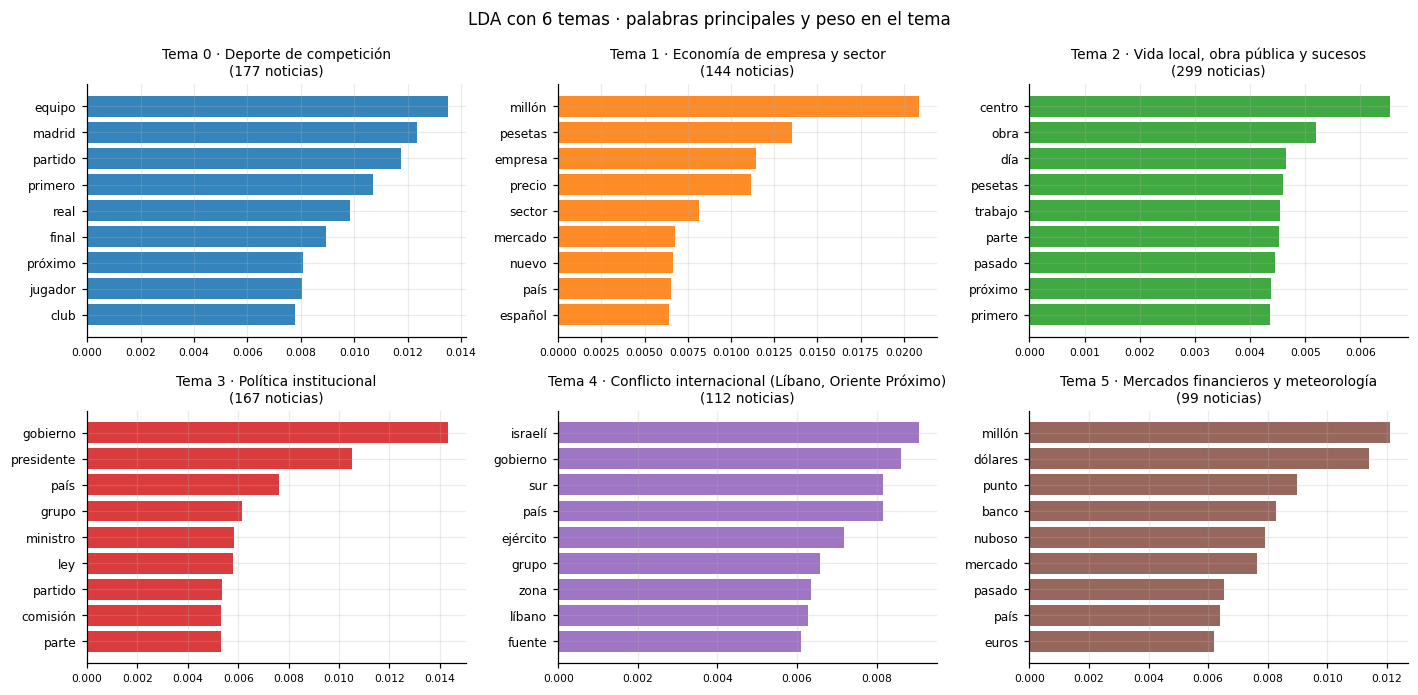

In [23]:
# Etiquetas interpretativas asignadas a mano a partir de las palabras principales de cada tema.
ETIQUETAS_TEMA = {
    0: "Deporte de competición",
    1: "Economía de empresa y sector",
    2: "Vida local, obra pública y sucesos",
    3: "Política institucional",
    4: "Conflicto internacional (Líbano, Oriente Próximo)",
    5: "Mercados financieros y meteorología",
}
tabla_temas = pd.DataFrame({
    "tema": range(K),
    "etiqueta interpretativa": [ETIQUETAS_TEMA[t] for t in range(K)],
    "palabras principales": [", ".join(w for w, _ in lda.show_topic(t, 10)) for t in range(K)],
    "noticias": np.bincount(dominante, minlength=K),
})
METRICAS["mineria"]["lda"] = {
    "temas": K,
    "coherencia_cv": round(float(barrido_lda.set_index("temas").loc[K, "coherencia c_v"]), 4),
    "ami": round(float(barrido_lda.set_index("temas").loc[K, "AMI frente a lo anotado"]), 4),
    "pureza": round(float(barrido_lda.set_index("temas").loc[K, "pureza"]), 4),
    "prob_media_dominante": round(float(theta.max(1).mean()), 3),
    "tabla": tabla_temas.assign(noticias=lambda d: d.noticias.astype(int)).to_dict("records"),
}
display(tabla_temas)

cruce_lda = pd.crosstab(pd.Series(etiquetas_oro, name="tema anotado"),
                        pd.Series([ETIQUETAS_TEMA[t] for t in dominante[idx_oro]], name="tema LDA"))
display(cruce_lda)

fig, ejes = plt.subplots(2, 3, figsize=(13, 6.4))
for t, eje in enumerate(ejes.ravel()):
    palabras = lda.show_topic(t, 9)[::-1]
    eje.barh([w for w, _ in palabras], [p for _, p in palabras], color=plt.cm.tab10(t), alpha=0.9)
    eje.set_title(f"Tema {t} · {ETIQUETAS_TEMA[t]}\n({np.bincount(dominante, minlength=K)[t]} noticias)",
                  fontsize=9)
    eje.tick_params(axis="y", labelsize=8); eje.tick_params(axis="x", labelsize=7)
fig.suptitle(f"LDA con {K} temas · palabras principales y peso en el tema", fontsize=11)
fig.tight_layout()
guardar_figura("fig06_08_lda_temas")

**Análisis.** Se interpreta el modelo de seis temas: es el punto en que la coherencia $c_v$ ya ha dejado de
crecer apreciablemente (0,435 con cinco temas, 0,467 con seis, 0,479 con ocho) y la partición sigue siendo
legible. Los temas 0, 1, 3 y 4 se dejan etiquetar sin esfuerzo (deporte, economía de empresa, política
institucional y el conflicto del sur del Líbano), mientras que el 2 mezcla vida municipal con sucesos y el 5 une
mercados financieros con el parte meteorológico —dos contenidos sin relación semántica que comparten, en cambio,
la forma: tablas de cifras y vocabulario técnico breve—.

La comparación de las dos evaluaciones es el resultado metodológico de la sección. La coherencia **sube**
monótonamente de 0,435 (5 temas) a 0,479 (8 temas), mientras la AMI frente a las categorías anotadas **baja** de 0,845 a
0,632. No es contradictorio: al aumentar $K$, LDA parte los temas grandes en subtemas más específicos y por
tanto más coherentes internamente, pero se aleja de la granularidad de las cinco categorías humanas. Elegir $K$
por coherencia optimiza la legibilidad de cada tema; elegirlo por acuerdo con una taxonomía optimiza otra cosa.
Con $K$ = 5 la AMI es 0,845 y la pureza 0,871, la mejor correspondencia del barrido, y no por casualidad:
coincide con el número de categorías anotadas.

La tabla cruzada muestra dónde falla el acuerdo con $K$ = 6. *Deportes* y *política* se recuperan casi
perfectamente (14 de 14 y 12 de 14), pero *economía* se parte en dos —9 noticias al tema de mercados y 4 al de
economía de empresa—, *cultura* no tiene tema propio y cae mayoritariamente (11 de 14) en el tema de vida local,
y, lo más llamativo, **5 de las 14 noticias de sucesos y justicia acaban en el tema del sur del Líbano**: el
vocabulario de violencia, seguridad y fuerzas armadas es el mismo en un atentado y en un conflicto armado, y LDA
solo ve palabras. Las culturales (exposiciones, presentaciones de libros, conciertos municipales) comparten
vocabulario administrativo —*centro*, *obra*, *pesetas*— con la información local. La probabilidad media del tema
dominante es 0,789, lo
que confirma que LDA está asignando mezclas, no etiquetas duras: una noticia sobre el presupuesto de un museo es
legítimamente economía, cultura y política local a la vez, y ahí la anotación humana en categorías excluyentes es
la que simplifica.

### 4.4 Agrupamiento con k-medias sobre TF-IDF y LSA

El agrupamiento ataca el mismo problema con otra hipótesis: no mezclas de temas, sino **particiones duras** en el
espacio vectorial. Se representa cada noticia con TF-IDF sobre los lemas de contenido, se reduce a 100
dimensiones con **LSA** (`TruncatedSVD`, que elimina ruido y hace comparable la distancia euclídea a la
similitud del coseno tras normalizar) y se agrupa con k-medias. Se evalúa con la **silueta** (intrínseca) y con
**AMI y pureza** frente a las 70 noticias anotadas (extrínsecas).

In [24]:
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

textos_lemas = [" ".join(d) for d in docs_lemas]
vectorizador = TfidfVectorizer(min_df=5, max_df=0.4, sublinear_tf=True)
X_tfidf = vectorizador.fit_transform(textos_lemas)
svd = TruncatedSVD(n_components=100, random_state=SEED)
X_lsa = make_pipeline(svd, Normalizer(copy=False)).fit_transform(X_tfidf)
print(f"TF-IDF: {X_tfidf.shape} | LSA: {X_lsa.shape} | "
      f"varianza explicada por 100 componentes: {svd.explained_variance_ratio_.sum():.1%}")

filas = []
for k in (5, 6, 7, 8):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_lsa)
    filas.append({"grupos": k, "silueta": silhouette_score(X_lsa, km.labels_),
                  "AMI frente a lo anotado": adjusted_mutual_info_score(etiquetas_oro, km.labels_[idx_oro]),
                  "pureza": pureza(etiquetas_oro, km.labels_[idx_oro])})
barrido_km = pd.DataFrame(filas)
METRICAS["mineria"]["kmedias_barrido"] = barrido_km.round(4).to_dict("records")
display(barrido_km.style.format({"silueta": "{:.4f}", "AMI frente a lo anotado": "{:.4f}", "pureza": "{:.4f}"}))

TF-IDF: (998, 3238) | LSA: (998, 100) | varianza explicada por 100 componentes: 33.5%


,grupos,silueta,AMI frente a lo anotado,pureza
0,5,0.0405,0.8901,0.9429
1,6,0.0418,0.7725,0.9000
2,7,0.0443,0.8241,0.9286
3,8,0.0458,0.7658,0.9143


In [25]:
K_KM = 5  # se interpreta con cinco grupos, el número de categorías anotadas
kmedias = KMeans(n_clusters=K_KM, random_state=SEED, n_init=10).fit(X_lsa)
grupos = kmedias.labels_
terminos = np.array(vectorizador.get_feature_names_out())
centros_tfidf = svd.inverse_transform(kmedias.cluster_centers_)  # vuelta al espacio de términos

ETIQUETAS_GRUPO = {}
for g in range(K_KM):
    principales = terminos[np.argsort(centros_tfidf[g])[::-1][:10]]
    print(f"Grupo {g} ({np.bincount(grupos, minlength=K_KM)[g]} noticias):", ", ".join(principales))

ami_km = adjusted_mutual_info_score(etiquetas_oro, grupos[idx_oro])
pureza_km = pureza(etiquetas_oro, grupos[idx_oro])
print(f"\nAMI: {ami_km:.4f} | pureza: {pureza_km:.4f} | silueta: {silhouette_score(X_lsa, grupos):.4f}")
cruce_km = pd.crosstab(pd.Series(etiquetas_oro, name="tema anotado"),
                       pd.Series(grupos[idx_oro], name="grupo k-medias"))
display(cruce_km)

Grupo 0 (160 noticias): millón, dólares, mercado, precio, sector, empresa, banco, bolsa, punto, euros
Grupo 1 (159 noticias): equipo, jugador, liga, partido, club, temporada, final, real, primero, madrid
Grupo 2 (318 noticias): ayuntamiento, obra, pesetas, centro, municipal, millón, nuevo, proyecto, trabajo, gobierno
Grupo 3 (221 noticias): presidente, gobierno, país, ministro, partido, político, portavoz, general, reunión, elección
Grupo 4 (140 noticias): policía, fuente, civil, acusado, vehículo, víctima, agente, caso, persona, hora

AMI: 0.8901 | pureza: 0.9429 | silueta: 0.0405


grupo k-medias,0,1,2,3,4
tema anotado,,,,,
cultura,0,0,14,0,0
deportes,0,13,1,0,0
economía,14,0,0,0,0
política,0,0,3,11,0
sucesos y justicia,0,0,0,0,14


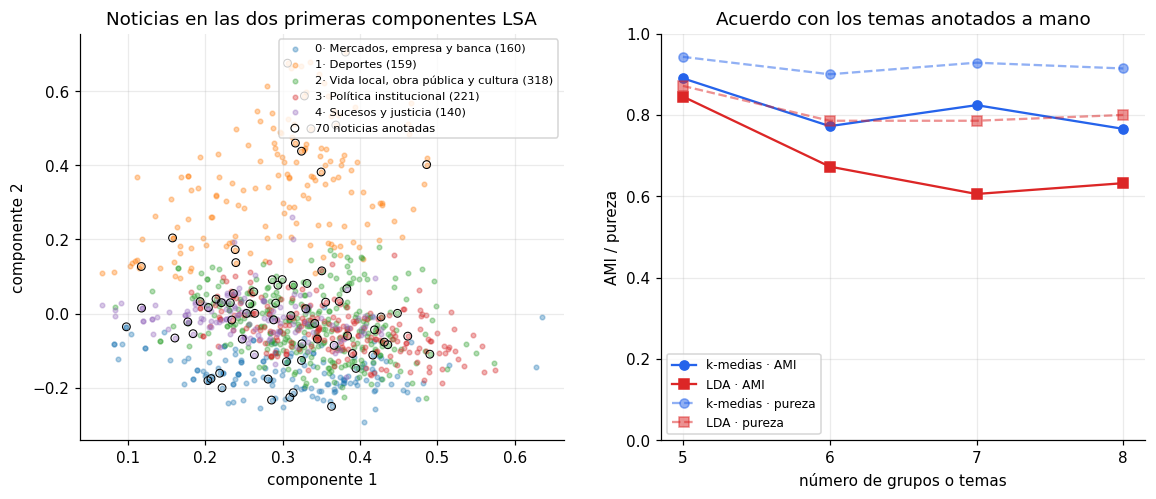

In [26]:
ETIQUETAS_GRUPO = {
    0: "Mercados, empresa y banca",
    1: "Deportes",
    2: "Vida local, obra pública y cultura",
    3: "Política institucional",
    4: "Sucesos y justicia",
}
METRICAS["mineria"]["kmedias"] = {
    "grupos": K_KM,
    "ami": round(float(ami_km), 4), "pureza": round(float(pureza_km), 4),
    "silueta": round(float(silhouette_score(X_lsa, grupos)), 4),
    "varianza_lsa": round(float(svd.explained_variance_ratio_.sum()), 4),
    "tamanos": np.bincount(grupos, minlength=K_KM).tolist(),
    "etiquetas": ETIQUETAS_GRUPO,
    "terminos": {g: terminos[np.argsort(centros_tfidf[g])[::-1][:10]].tolist() for g in range(K_KM)},
}

fig, ejes = plt.subplots(1, 2, figsize=(12.5, 4.8))
eje = ejes[0]
for g in range(K_KM):
    m = grupos == g
    eje.scatter(X_lsa[m, 0], X_lsa[m, 1], s=9, alpha=0.35, color=plt.cm.tab10(g),
                label=f"{g}· {ETIQUETAS_GRUPO[g]} ({m.sum()})")
eje.scatter(X_lsa[idx_oro, 0], X_lsa[idx_oro, 1], s=26, facecolors="none", edgecolors="k", lw=0.7,
            label="70 noticias anotadas")
eje.set(title="Noticias en las dos primeras componentes LSA", xlabel="componente 1", ylabel="componente 2")
eje.legend(fontsize=7.5, loc="best")

eje = ejes[1]
eje.plot(barrido_km.grupos, barrido_km["AMI frente a lo anotado"], "o-", color=AZUL, label="k-medias · AMI")
eje.plot(barrido_lda.temas, barrido_lda["AMI frente a lo anotado"], "s-", color=ROJO, label="LDA · AMI")
eje.plot(barrido_km.grupos, barrido_km.pureza, "o--", color=AZUL, alpha=0.5, label="k-medias · pureza")
eje.plot(barrido_lda.temas, barrido_lda.pureza, "s--", color=ROJO, alpha=0.5, label="LDA · pureza")
eje.set(title="Acuerdo con los temas anotados a mano", xlabel="número de grupos o temas",
        ylabel="AMI / pureza", ylim=(0, 1), xticks=[5, 6, 7, 8])
eje.legend(fontsize=8)
guardar_figura("fig06_09_kmedias_lsa")

**Análisis.** Con cinco grupos, k-medias sobre LSA alcanza **AMI = 0,890** y **pureza = 0,943** frente a
la anotación humana: de las 70 noticias etiquetadas, 66 caen en el grupo mayoritario de su categoría.
La tabla cruzada es casi diagonal: *economía*, *sucesos y justicia* y *cultura* quedan sin un solo error (14 de 14
cada una) y *deportes* pierde una noticia. El único desacuerdo sistemático es *política*, que cede 3 de sus 14
noticias al grupo de vida local y obra pública —son noticias de política **municipal**, donde el léxico de
ayuntamiento y presupuesto pesa más que el de partidos—. Conviene precisar qué significa el acierto en *cultura*:
las 14 noticias culturales caen juntas, pero en un grupo de 318 documentos que es mayoritariamente
información local, de modo que el método las agrupa correctamente **sin darles una categoría propia**.

Que k-medias supere tan claramente a LDA en el acuerdo con la anotación (0,890 frente a 0,673 con seis
temas) merece una explicación, porque **no significa que sea un mejor modelo del corpus**:

1. **La tarea de evaluación favorece las particiones duras.** La referencia asigna a cada noticia una única
   categoría; k-medias hace exactamente eso, mientras LDA entrega mezclas que hay que aplanar con `argmax`, un
   paso que descarta información y penaliza el modelo en la métrica.
2. **TF-IDF penaliza lo genérico y LDA no.** La ponderación IDF rebaja el peso de las palabras que aparecen en
   muchos documentos, justo las que contaminaban los temas de LDA; el modelo de temas trabaja sobre conteos
   crudos y por eso términos administrativos comunes se cuelan en varios temas.
3. **Las anotaciones fueron elegidas para ser separables.** Las 70 noticias son casos claros de cinco
   categorías, con 14 por clase: un escenario amable para un método que busca grupos compactos.

El precio de k-medias se ve en la silueta: **0,041**, un valor cercano a cero que indica que los grupos **no
están separados geométricamente**, sino que son cortes en una nube continua. Es lo normal en texto de alta
dimensión y explica por qué el panel de LSA muestra una nube sin fronteras visibles: las dos primeras componentes
retienen solo una fracción de la varianza (las 100 componentes juntas explican el 33,5 %), y las categorías
temáticas se distinguen en direcciones que no son las dos primeras. La silueta también avisa de que el número de
grupos no está determinado por los datos: varía entre 0,041 y 0,046 en todo el barrido de 5 a 8
grupos, es decir, **es incapaz de elegir $K$**. La AMI sí discrimina —es máxima con 5 grupos—, pero exige unas
etiquetas de referencia que en un caso real no existirían. Elegir $K$ sigue siendo una decisión del analista.

### 4.5 Nube de palabras

La nube de palabras es una herramienta de comunicación, no de análisis: codifica la frecuencia en el tamaño de la
tipografía, una variable visual que el ojo compara mal. Se incluye porque resume el corpus de un vistazo, y se
construye **sobre lemas de contenido** para que muestre de qué se habla y no la gramática del español.

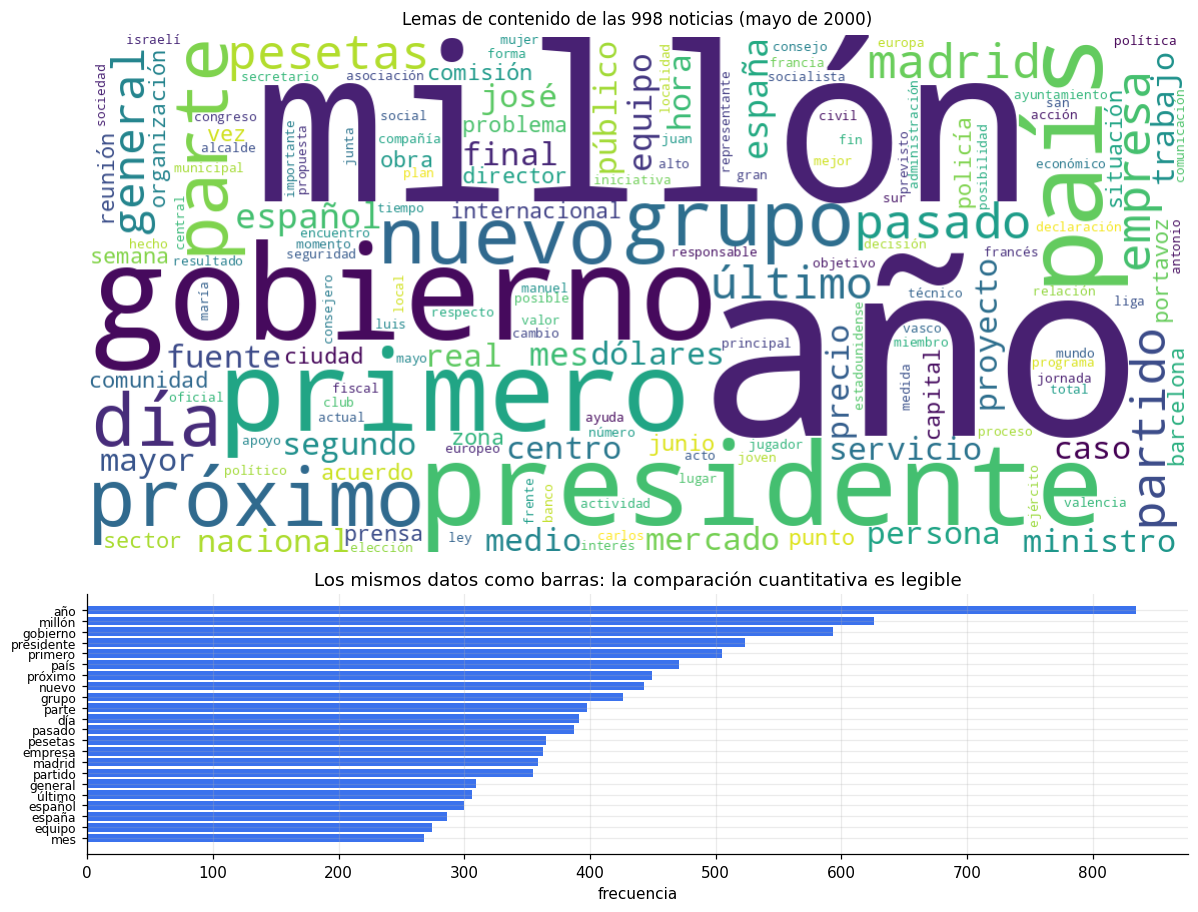

Lemas de contenido distintos: 14699


In [27]:
from wordcloud import WordCloud

frecuencias_lemas = Counter(w for d in docs_lemas for w in d)
nube = WordCloud(width=1100, height=520, background_color="white", colormap="viridis",
                 random_state=SEED, max_words=160, collocations=False)
nube.generate_from_frequencies(frecuencias_lemas)

fig, ejes = plt.subplots(2, 1, figsize=(11, 8.4), height_ratios=[2, 1])
ejes[0].imshow(nube.to_array(), interpolation="bilinear")
ejes[0].axis("off"); ejes[0].grid(False)
ejes[0].set_title("Lemas de contenido de las 998 noticias (mayo de 2000)", fontsize=11)

top = frecuencias_lemas.most_common(22)[::-1]
ejes[1].barh([w for w, _ in top], [c for _, c in top], color=AZUL, alpha=0.9)
ejes[1].set(title="Los mismos datos como barras: la comparación cuantitativa es legible", xlabel="frecuencia")
ejes[1].tick_params(axis="y", labelsize=8)
fig.tight_layout()
guardar_figura("fig06_10_nube_palabras")
METRICAS["mineria"]["lemas_frecuentes"] = [{"lema": w, "frecuencia": c}
                                           for w, c in frecuencias_lemas.most_common(20)]
print("Lemas de contenido distintos:", len(frecuencias_lemas))

**Análisis.** La nube y el diagrama de barras contienen exactamente la misma información y solo el segundo permite
afirmar algo cuantitativo: *año* aparece 834 veces y *millón* 626, una diferencia que en
la nube es indistinguible porque el área del texto no escala de forma perceptualmente lineal con la frecuencia.
Vale como portada de un informe; no como evidencia.

Lo que sí revela el conteo es la **capa más genérica del vocabulario periodístico**: los lemas más frecuentes son
*año*, *millón*, *gobierno*, *presidente*, *españa*, *día* —unidades de tiempo, de dinero y actores
institucionales—. Es el fondo común de casi cualquier corpus de prensa, y explica por qué el filtro
`max_df = 0,4` y la ponderación IDF fueron necesarios en las secciones anteriores: sin ellos, estos términos
dominan cualquier tema y cualquier grupo.

### 4.6 Interpretación: la agenda informativa de mayo de 2000

Los tres métodos no supervisados —n-gramas frecuentes, colocaciones y modelado de temas— convergen en una misma
descripción del mes, y esa convergencia es la que permite tratarla como un hallazgo y no como un artefacto de un
algoritmo.

In [28]:
# Convergencia de los tres métodos: cuántas noticias asigna cada uno a cada eje temático.
resumen_agenda = pd.DataFrame({
    "tema LDA (K=6)": [ETIQUETAS_TEMA[t] for t in range(K)],
    "noticias LDA": np.bincount(dominante, minlength=K),
}).sort_values("noticias LDA", ascending=False)
display(resumen_agenda.reset_index(drop=True))
display(pd.DataFrame({"grupo k-medias": [ETIQUETAS_GRUPO[g] for g in range(K_KM)],
                      "noticias": np.bincount(grupos, minlength=K_KM)}).sort_values("noticias", ascending=False)
        .reset_index(drop=True))
METRICAS["mineria"]["agenda"] = {ETIQUETAS_GRUPO[g]: int(n) for g, n in enumerate(np.bincount(grupos, minlength=K_KM))}

,tema LDA (K=6),noticias LDA
0,"Vida local, obra pública y sucesos",299
1,Deporte de competición,177
2,Política institucional,167
3,Economía de empresa y sector,144
4,"Conflicto internacional (Líbano, Oriente Próximo)",112
5,Mercados financieros y meteorología,99


,grupo k-medias,noticias
0,"Vida local, obra pública y cultura",318
1,Política institucional,221
2,"Mercados, empresa y banca",160
3,Deportes,159
4,Sucesos y justicia,140


**Análisis.** La agenda que emerge de las 998 noticias tiene cuatro rasgos.

1. **La economía ocupa el primer plano y se mide en dos monedas.** Los bigramas más frecuentes del corpus son
   *millón pesetas* (203) y *millón dólares* (135), y las colocaciones por PMI recogen *wall
   street* y *dow jones*. El detalle de la doble moneda fecha el corpus con precisión: mayo de 2000 es el período
   de transición hacia el euro, cuando la peseta sigue siendo la unidad de cuenta doméstica y el dólar la
   referencia internacional. Un tema de LDA (el 5) y un grupo de k-medias («mercados y banca», 160 noticias)
   se organizan enteramente alrededor de esto.
2. **La política española es institucional y personalizada.** Los trigramas más frecuentes incluyen *josé maría
   aznar*, *presidente gobierno josé* y *don juan carlos*; el tema 3 de LDA se articula sobre *gobierno*,
   *presidente*, *ministro*, *ley*, *comisión*, y el grupo homólogo de k-medias añade *portavoz*, *reunión* y
   *elección*. La agenda política es la de la actividad oficial —comparecencias, proyectos de ley, comisiones—, no
   la del conflicto partidista.
3. **Dos focos internacionales concretos, no una sección genérica de exterior.** LDA aísla un tema completo
   (112 noticias) alrededor de *israelí*, *sur*, *líbano*, *ejército*, *zona*: la retirada israelí del sur
   del Líbano de mayo de 2000. Las colocaciones añaden *sierra leona*, *cascos azules* e *intentona golpista*, es
   decir, la crisis de los cascos azules en Sierra Leona. Que el modelo dedique un tema entero a un episodio de un
   mes concreto demuestra que LDA describe **este** corpus, no el periodismo en general: cambiar el mes cambiaría
   el tema.
4. **El deporte se concentra en un acontecimiento.** *real madrid* es la colocación con mayor log-verosimilitud
   del corpus y *final liga campeones* el segundo trigrama más frecuente: la final de la Liga de Campeones del 24
   de mayo de 2000 satura la sección.

**Frente a las cinco categorías anotadas a mano**, el contraste es instructivo:

- **Coinciden bien cuatro**: *economía*, *sucesos y justicia*, *deportes* y *política* se recuperan casi
  perfectamente con k-medias (14, 14, 13 y 11 noticias de 14) y las tres primeras son reconocibles también en los
  temas de LDA. Son categorías con vocabulario propio y poco compartido.
- **Se recupera mal una**: *cultura* no obtiene tema ni grupo propio en ninguno de los dos métodos. Con k-medias
  sus 14 noticias quedan juntas, pero absorbidas en un grupo de 318 documentos de información local; con LDA
  se reparten entre vida local (11), economía de empresa (2) y mercados (1). La razón es que las noticias
  culturales del corpus no hablan de obras sino de su **gestión**: subvenciones, inauguraciones, presentaciones
  oficiales. Comparten léxico administrativo con lo institucional, y ningún método basado en coocurrencia de
  palabras puede separar lo que el léxico no separa.
- **Los métodos descubren ejes que la anotación no tiene**: el eje geográfico —local frente a nacional frente a
  internacional— atraviesa las cinco categorías y es el que domina el agrupamiento; y el tema del sur del Líbano
  es un **acontecimiento**, no una sección de periódico. Una taxonomía temática estable no puede contener
  categorías que duran un mes, pero un modelo no supervisado las encuentra porque están en los datos. Un tercer eje aparece por accidente: el tema 5
de LDA une mercados financieros con el parte meteorológico (*nuboso* entre sus palabras principales), dos
contenidos que solo comparten el **formato** de tabla de cifras. LDA agrupa por coocurrencia, y la coocurrencia no
distingue el tema del género textual.

La conclusión metodológica: la anotación humana y los métodos no supervisados no compiten por la misma respuesta.
La primera impone una estructura estable y comparable entre corpus; los segundos describen **lo que este corpus
tiene de particular**, incluidos el ruido de formato (*may efe*), la coyuntura monetaria y los episodios
irrepetibles. Un sistema de producción necesita las dos cosas: la taxonomía para archivar y el modelo no
supervisado para detectar lo que la taxonomía no previó. Y conviene recordar el orden de magnitud del ejercicio:
las 70 noticias anotadas son el 7 % del corpus, así que todo lo dicho sobre el acuerdo entre métodos y anotación
descansa en una muestra pequeña y deliberadamente clara.

## 5. Métricas y hallazgos

In [29]:
(DIR_RES / "metricas_06.json").write_text(
    json.dumps(METRICAS, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Guardado:", DIR_RES / "metricas_06.json")
print("Figuras:", sorted(p.name for p in DIR_FIG.glob("fig06_*.png")))
print(json.dumps({k: (list(v) if isinstance(v, dict) else v) for k, v in METRICAS.items()},
                 ensure_ascii=False, indent=1)[:900], "…")

Guardado: /home/claude/lab-procesamiento-texto/notebooks/resultados/metricas_06.json
Figuras: ['fig06_01_corpus_generacion.png', 'fig06_02_ngramas_perplejidad.png', 'fig06_03_lstm_entrenamiento.png', 'fig06_04_temperatura_diversidad.png', 'fig06_05_llm_vs_entrenado.png', 'fig06_06_ngramas_frecuentes.png', 'fig06_07_colocaciones.png', 'fig06_08_lda_temas.png', 'fig06_09_kmedias_lsa.png', 'fig06_10_nube_palabras.png']
{
 "corpus_generacion": [
  "lineas",
  "palabras",
  "tokens_tokenizador",
  "vocabulario_completo",
  "vocabulario_usado",
  "cobertura_tokens"
 ],
 "ngramas": [
  "tabla",
  "vocabulario",
  "contextos_bigramas",
  "contextos_trigramas",
  "ppl_validacion_bigramas",
  "ppl_validacion_trigramas",
  "ppl_entrenamiento_bigramas",
  "ppl_entrenamiento_trigramas"
 ],
 "lstm": [
  "parametros",
  "maxlen",
  "epocas",
  "segundos_entrenamiento",
  "ejemplos_entrenamiento",
  "ejemplos_validacion",
  "perdida_entrenamiento_mejor_epoca",
  "mejor_perdida_validacion",
  "mejor_ep

## 6. Hallazgos del notebook

- **Los trigramas generalizan peor que los bigramas** con este volumen de datos: perplejidad de 1.199,9 frente
  a 407,2 en validación, pese a ajustar mejor el entrenamiento. El 73,2 % de los contextos de trigrama
  tiene una única continuación observada, de modo que el modelo memoriza en lugar de aprender. Es el problema de
  dispersión que motiva el suavizado y, más allá, los modelos neuronales.
- **La red `Embedding` + `Bidirectional(LSTM)` del laboratorio de clase reduce la perplejidad un 51,7 %**
  (196,8 frente a 407,2) con 1.408.905 parámetros y unos 90 segundos de entrenamiento en CPU. La
  ganancia proviene de la representación distribuida, que comparte información entre palabras de contexto
  parecido. Su exactitud de siguiente palabra (21,0 %) no mide la calidad del generador: la tarea es
  intrínsecamente ambigua.
- **La búsqueda voraz degenera y el top-k es la mejor corrección**: con búsqueda voraz, el 45,6 % de los
  bigramas y el 32,0 % de los trigramas generados por la red son repeticiones internas (*«de la junta de la
  junta de la consejería»*), frente al 0,4 % de trigramas con top-k = 10. La temperatura gobierna el
  compromiso entre coherencia y diversidad (distinct-2 de 0,496 con $T$ = 0,2, todavía atrapado en el bucle, y
  0,956 con $T$ = 1,2, ya incoherente), pero recortar la cola de candidatos es más eficaz que reescalar toda
  la distribución (Holtzman et al., 2020). La degeneración solo se observa en textos largos: con 20 palabras por
  generación no aparecía ninguna repetición de trigramas, y por eso se fijaron 40.
- **Instruir un modelo preentrenado y entrenar uno propio son métodos distintos, no versiones del mismo.** El
  registro de 10 experimentos de prompting muestra control por instrucción, conocimiento del mundo y coherencia
  inalcanzables con 57.172 palabras de entrenamiento, y el 16,5 % de su léxico queda fuera del
  vocabulario de 5.000 palabras de la sección 2. El precio son riesgos de distinta naturaleza: invención de datos
  indistinguible de la recuperación correcta, coste por llamada, dependencia de un proveedor y **no
  reproducibilidad** —este notebook no puede reejecutar la sección 3, y esa limitación se declara en lugar de
  disimularse—.
- **La log-verosimilitud y el PMI extraen terminología distinta y complementaria** de los mismos 259
  candidatos: la primera devuelve términos con respaldo estadístico (*real madrid*, *medio ambiente*, *unión
  europea*), el segundo expresiones fijas casi indivisibles (*wall street*, *dow jones*, *cascos azules*). La
  frecuencia a secas solo devuelve fórmulas del oficio (*informó hoy*).
- **Coherencia y acuerdo con una taxonomía humana apuntan en direcciones opuestas**: al pasar de 5 a 8 temas, la
  coherencia $c_v$ de LDA sube de 0,435 a 0,479 mientras la AMI frente a las 70 noticias anotadas cae de
  0,845 a 0,632. Más temas son internamente más coherentes y menos comparables con las categorías humanas;
  elegir $K$ es una decisión sobre qué se quiere optimizar.
- **K-medias sobre TF-IDF y LSA recupera la anotación humana casi por completo** (AMI = 0,890, pureza =
  0,943; 66 de las 70 noticias anotadas en el grupo mayoritario de su categoría, con *economía*,
  *sucesos y justicia* y *cultura* sin un solo error), muy por encima de LDA (0,673 con seis temas). La
  ventaja es en parte del método —TF-IDF penaliza lo genérico, la partición dura coincide con el formato de la
  referencia— y en parte del escenario de evaluación. Su silueta de 0,041 recuerda que los grupos son cortes
  en una nube continua, no regiones separadas, y que la silueta no sirve para elegir $K$: varía entre 0,041 y
  0,046 en todo el barrido.
- **La agenda descubierta fecha el corpus**: doble unidad monetaria peseta-dólar (203 y 135
  ocurrencias), la final de la Liga de Campeones, la retirada israelí del sur del Líbano y la crisis de Sierra
  Leona. De las cinco categorías anotadas se recuperan cuatro con nitidez; *cultura* queda absorbida en la
  información local porque el corpus habla de la **gestión** cultural, no de las obras. A cambio, los métodos no
  supervisados descubren ejes que la taxonomía no contempla: el geográfico (local / nacional / internacional), el
  del acontecimiento puntual (la retirada del Líbano) y uno que no es temático en absoluto —el tema que une bolsa y
  parte meteorológico por compartir el formato de tabla de cifras—.
- **La minería detecta el ruido que el preprocesamiento dejó pasar**: el bigrama *may efe* aparece 59
  veces y ocuparía el puesto 6 entre los bigramas de contenido del texto crudo, lo que revela que
  `quitar_cabecera_agencia` solo limpia el inicio del documento y que la firma reaparece dentro de las notas
  refundidas. Los conteos de n-gramas son, además de un análisis, una auditoría del preprocesamiento.

## Referencias

- Bird, S., Klein, E. y Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly.
- Blei, D. M., Ng, A. Y. y Jordan, M. I. (2003). Latent Dirichlet Allocation. *Journal of Machine Learning Research*, 3, 993–1022.
- Brown, T. B., Mann, B., Ryder, N., Subbiah, M., Kaplan, J., Dhariwal, P., Neelakantan, A., Shyam, P., Sastry, G., Askell, A., Agarwal, S., Herbert-Voss, A., Krueger, G., Henighan, T., Child, R., Ramesh, A., Ziegler, D. M., Wu, J., Winter, C., … Amodei, D. (2020). Language models are few-shot learners. En *Advances in Neural Information Processing Systems* (Vol. 33, pp. 1877–1901).
- Church, K. W. y Hanks, P. (1990). Word association norms, mutual information, and lexicography. *Computational Linguistics*, 16(1), 22–29.
- Holtzman, A., Buys, J., Du, L., Forbes, M. y Choi, Y. (2020). The curious case of neural text degeneration. En *International Conference on Learning Representations (ICLR 2020)*. https://openreview.net/forum?id=rygGQyrFvH
- Honnibal, M., Montani, I., Van Landeghem, S. y Boyd, A. (2020). *spaCy: Industrial-strength Natural Language Processing in Python*. Zenodo. https://doi.org/10.5281/zenodo.1212303
- Moroney, L. (2019). *dlaicourse: Notebooks for learning deep learning* [Repositorio]. GitHub. https://github.com/lmoroney/dlaicourse
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Řehůřek, R. y Sojka, P. (2010). Software framework for topic modelling with large corpora. En *Proceedings of the LREC 2010 Workshop on New Challenges for NLP Frameworks* (pp. 45–50).
- Tjong Kim Sang, E. F. (2002). Introduction to the CoNLL-2002 shared task: Language-independent named entity recognition. En *Proceedings of CoNLL-2002* (pp. 155–158).